In [1]:
import pandas as pd
import pickle as pk
import networkx as nx
import collections
import random as rd
import itertools as it
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import gseapy as gp
from gseapy import dotplot

In [32]:
# Helper function to get distance 
def get_distance_index(disease_pair, distance_dict):
    return distance_dict.get(disease_pair) or distance_dict.get((disease_pair[1], disease_pair[0]))

# Helper function to generate unique disease pairs
def generate_unique_pairs(disease_list):
    return set(it.combinations(disease_list, 2))

# Function to calculate temporal distance across stages
def calculate_temporal_distance(trajectories_dict, distance_dict, step):
    temporal_dis = []
    for stage_dict in trajectories_dict.values():
        between_dis_dis_dict = {}
        stages = list(stage_dict.keys())
        for s1, s2 in it.combinations(stages, 2):
            if abs(s1 - s2) == step:
                for dis1, dis2 in it.product(stage_dict[s1], stage_dict[s2]):
                    if (dis1, dis2) not in between_dis_dis_dict and (dis2, dis1) not in between_dis_dis_dict:
                        disease_pair = (dis1, dis2)
                        dis = get_distance_index(disease_pair, distance_dict)
                        if dis is not None:
                            between_dis_dis_dict[disease_pair] = dis
        temporal_dis.extend(between_dis_dis_dict.values())
    return temporal_dis

In this notebook, we will explore the molecular relationship of diseases within the same trajectory in the interactome.
We will show that diseases belonging to the same trajectories and in adjacient stages tend to be closer from a molecular point of view (the associated proteins/genes are more similar compared to random pairwise)

In [2]:
#The network distances are caculated in the Python script Elma_distance_script.py and here imported

In [3]:
#Let's import the results that were calculated in the cluster


with open('output/icd_genes_ppi_overlap_coefficient_dict.pickle', 'rb') as handle:
    icd_genes_ppi_overlap_coefficient_dict = pk.load(handle)

with open('output/icd_genes_ppi_overlap_jaccard_dict.pickle', 'rb') as handle:
    icd_genes_ppi_overlap_jaccard_dict = pk.load(handle)

with open('output/icd_genes_ppi_aspdc_dict.pickle', 'rb') as handle:
    icd_genes_ppi_aspdc_dict = pk.load(handle)

with open('output/icd_genes_ppi_mean_shortest_distance_dict.pickle', 'rb') as handle:
    icd_genes_ppi_mean_shortest_distance_dict = pk.load(handle)
    
with open('output/icd_genes_ppi_separation_dict.pickle', 'rb') as handle:
    icd_genes_ppi_separation_dict = pk.load(handle)


In [85]:
#Let's import the trajectories

with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.pickle', 'rb') as handle:
    male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = pk.load(handle)

with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.pickle', 'rb') as handle:
    female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = pk.load(handle)


## MALES

In [64]:

# Initialize lists
within_trj_time_ji_list = []
between_trj_time_ji_list = []
between_trj_adjacent_time_ji_list = []
same_trj_ji_list = []
never_same_trj_time_ji_list = []
never_same_trj_ji_list = []

# All possible Jaccard indices
all_dispairs_ji_list = list(icd_genes_ppi_overlap_jaccard_dict.values())

# Processing within trajectory comparisons
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_ji_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        within_dis_ji_set.add(disease_pair)
                        within_trj_time_ji_list.append(ji)

# Processing between stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_ji_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        between_dis_ji_set.add(disease_pair)
                        between_trj_time_ji_list.append(ji)

# Processing adjacent stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_ji_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        adjacent_dis_ji_set.add(disease_pair)
                        between_trj_adjacent_time_ji_list.append(ji)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in male_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, ji in icd_genes_ppi_overlap_jaccard_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_ji_list.append(ji)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, ji in icd_genes_ppi_overlap_jaccard_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_ji_list.append(ji)
    else:
        same_trj_ji_list.append(ji)


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3508273287.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


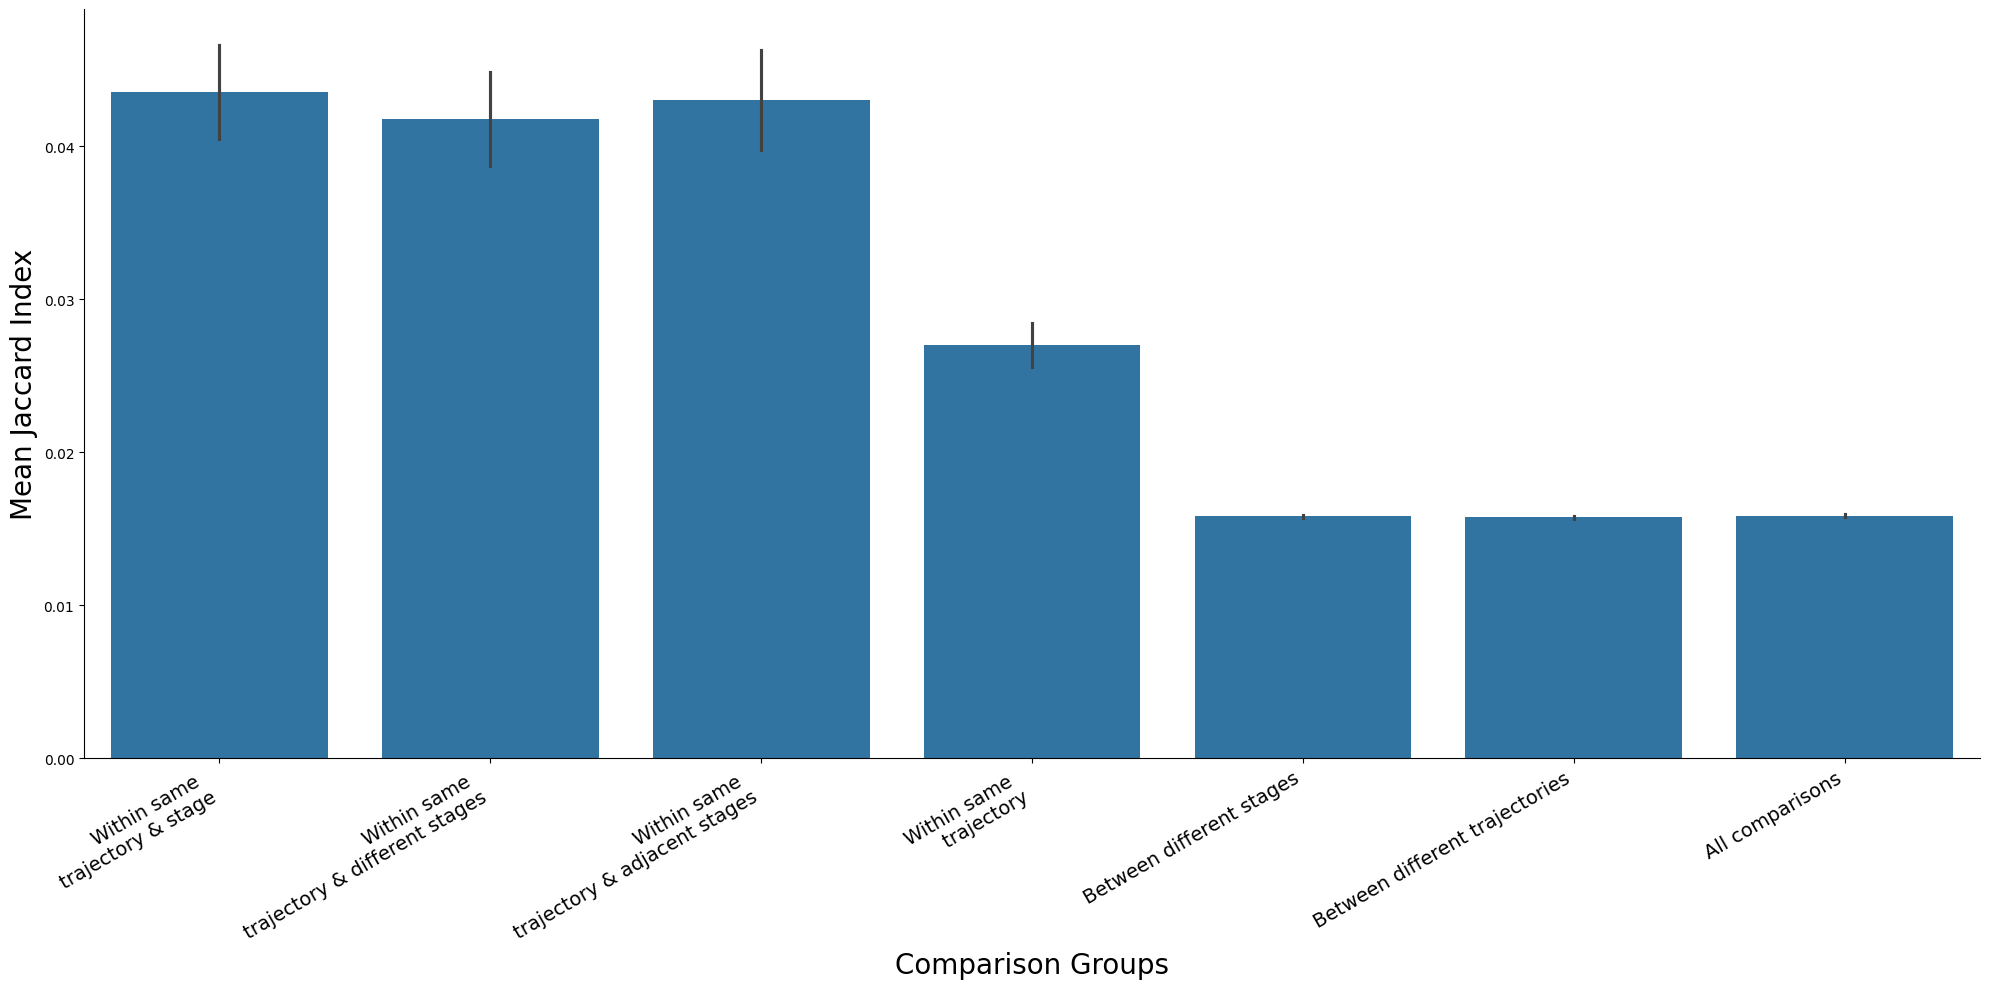

In [65]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_ji_list,
    between_trj_time_ji_list,
    between_trj_adjacent_time_ji_list,
    same_trj_ji_list,
    never_same_trj_time_ji_list,
    never_same_trj_ji_list,
    all_dispairs_ji_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Jaccard Index": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Jaccard Index"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Jaccard Index", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Jaccard Index', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisJI_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [66]:

# Initialize lists
within_trj_time_oc_list = []
between_trj_time_oc_list = []
between_trj_adjacent_time_oc_list = []
same_trj_oc_list = []
never_same_trj_time_oc_list = []
never_same_trj_oc_list = []

# All possible Jaccard indices
all_dispairs_oc_list = list(icd_genes_ppi_overlap_coefficient_dict.values())

# Processing within trajectory comparisons
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_oc_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        within_dis_oc_set.add(disease_pair)
                        within_trj_time_oc_list.append(oc)

# Processing between stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_oc_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        between_dis_oc_set.add(disease_pair)
                        between_trj_time_oc_list.append(oc)

# Processing adjacent stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_oc_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        adjacent_dis_oc_set.add(disease_pair)
                        between_trj_adjacent_time_oc_list.append(oc)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in male_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, oc in icd_genes_ppi_overlap_coefficient_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_oc_list.append(oc)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, oc in icd_genes_ppi_overlap_coefficient_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_oc_list.append(oc)
    else:
        same_trj_oc_list.append(oc)


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/400976662.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


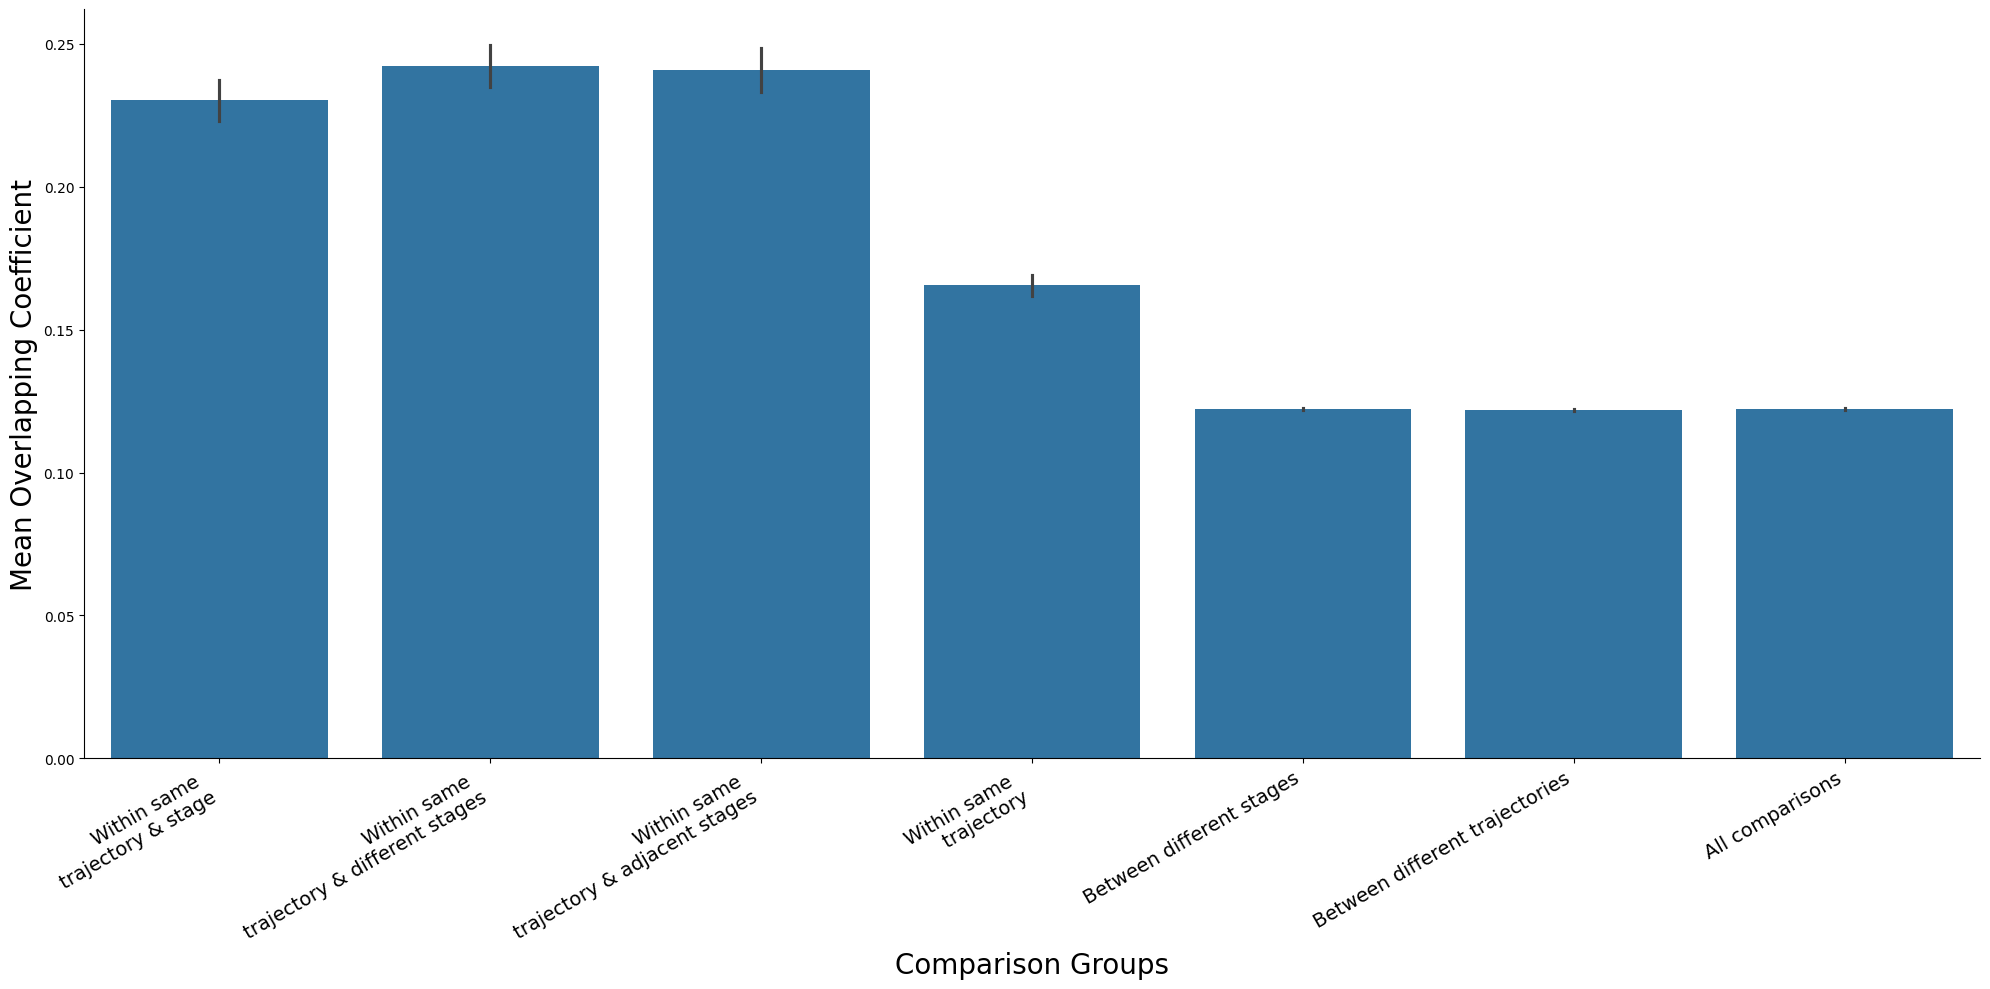

In [67]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_oc_list,
    between_trj_time_oc_list,
    between_trj_adjacent_time_oc_list,
    same_trj_oc_list,
    never_same_trj_time_oc_list,
    never_same_trj_oc_list,
    all_dispairs_oc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Overlapping Coefficient": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Overlapping Coefficient"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Overlapping Coefficient", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Overlapping Coefficient', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisOC_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [68]:

# Initialize lists
within_trj_time_aspdc_list = []
between_trj_time_aspdc_list = []
between_trj_adjacent_time_aspdc_list = []
same_trj_aspdc_list = []
never_same_trj_time_aspdc_list = []
never_same_trj_aspdc_list = []

# All possible Jaccard indices
all_dispairs_aspdc_list = list(icd_genes_ppi_aspdc_dict.values())

# Praspdcessing within trajectory comparisons
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_aspdc_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        within_dis_aspdc_set.add(disease_pair)
                        within_trj_time_aspdc_list.append(aspdc)

# Praspdcessing between stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_aspdc_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        between_dis_aspdc_set.add(disease_pair)
                        between_trj_time_aspdc_list.append(aspdc)

# Praspdcessing adjacent stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_aspdc_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        adjacent_dis_aspdc_set.add(disease_pair)
                        between_trj_adjacent_time_aspdc_list.append(aspdc)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in male_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, aspdc in icd_genes_ppi_aspdc_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_aspdc_list.append(aspdc)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, aspdc in icd_genes_ppi_aspdc_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_aspdc_list.append(aspdc)
    else:
        same_trj_aspdc_list.append(aspdc)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/2414210815.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


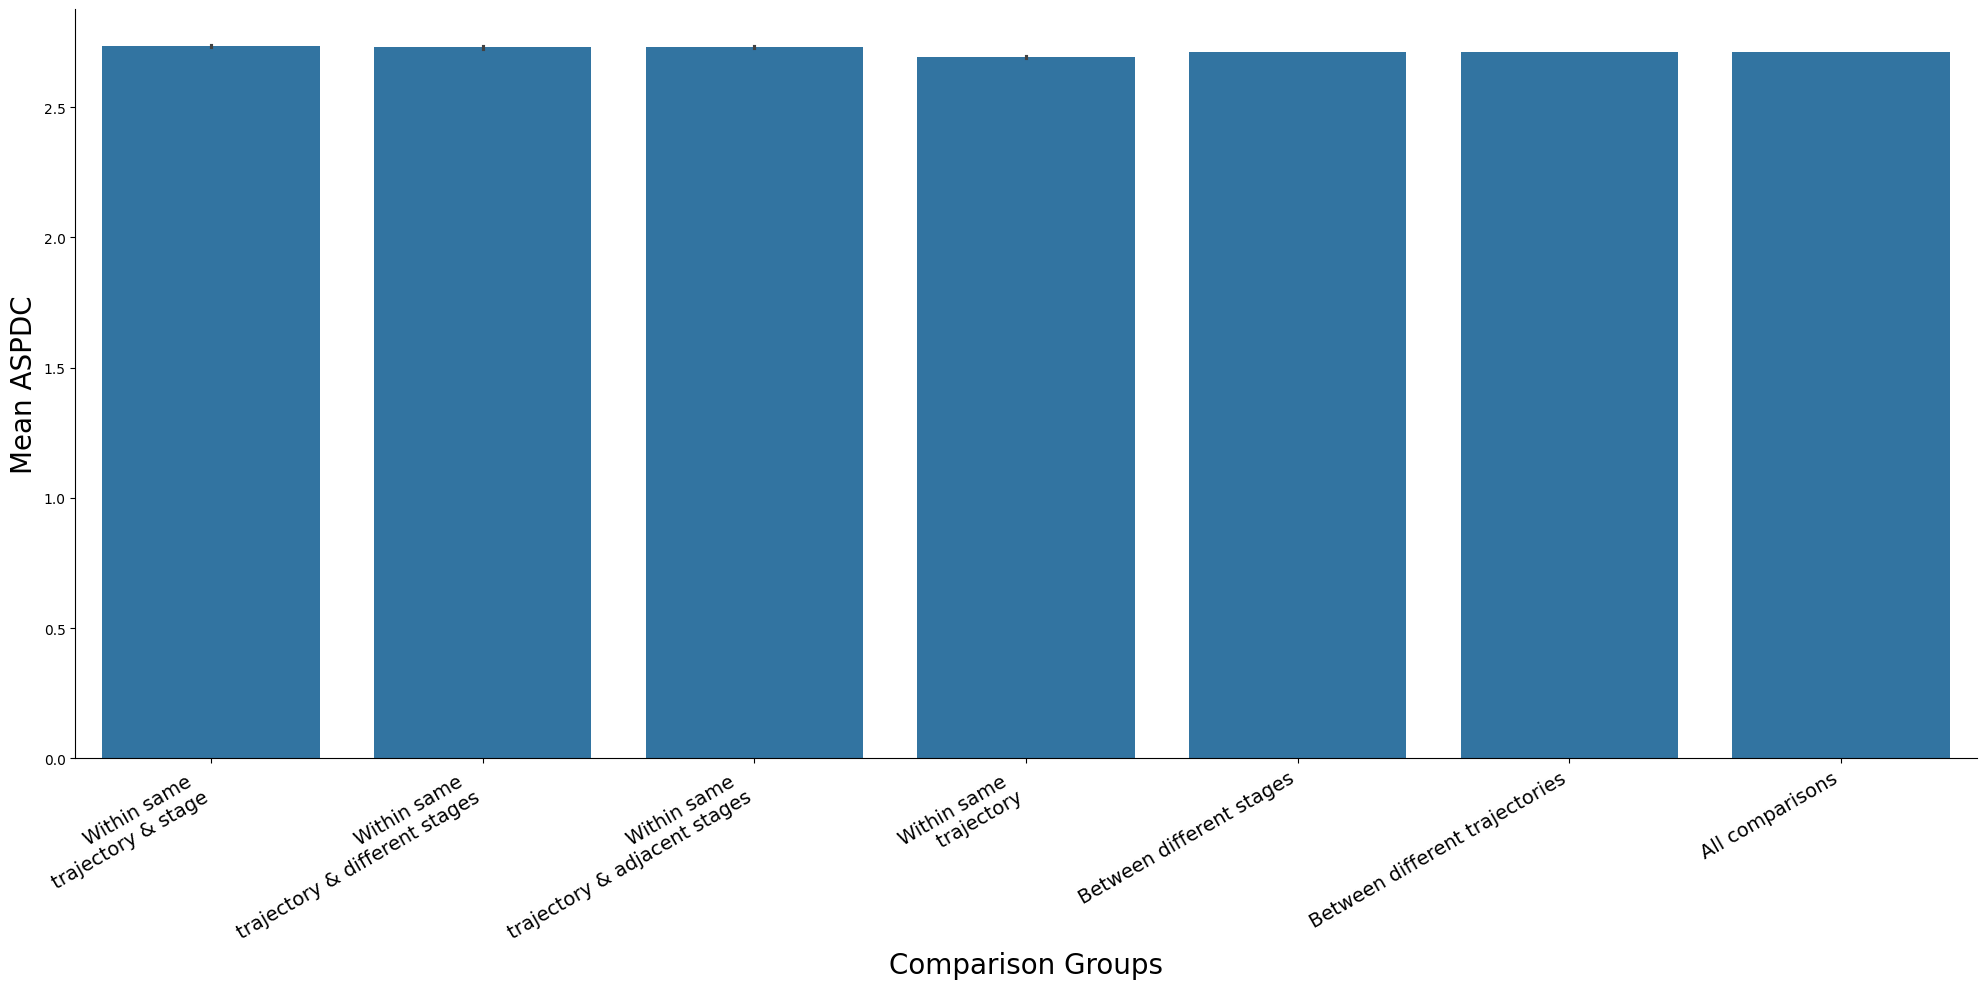

In [69]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_aspdc_list,
    between_trj_time_aspdc_list,
    between_trj_adjacent_time_aspdc_list,
    same_trj_aspdc_list,
    never_same_trj_time_aspdc_list,
    never_same_trj_aspdc_list,
    all_dispairs_aspdc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "ASPDC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["ASPDC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="ASPDC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean ASPDC', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisASPDC_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [70]:
# Initialize lists
within_trj_time_MinSHDIS_list = []
between_trj_time_MinSHDIS_list = []
between_trj_adjacent_time_MinSHDIS_list = []
same_trj_MinSHDIS_list = []
never_same_trj_time_MinSHDIS_list = []
never_same_trj_MinSHDIS_list = []

# All possible Jaccard indices
all_dispairs_MinSHDIS_list = list(icd_genes_ppi_mean_shortest_distance_dict.values())

# PrMinSHDISessing within trajectory comparisons
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_MinSHDIS_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        within_dis_MinSHDIS_set.add(disease_pair)
                        within_trj_time_MinSHDIS_list.append(MinSHDIS)

# PrMinSHDISessing between stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_MinSHDIS_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        between_dis_MinSHDIS_set.add(disease_pair)
                        between_trj_time_MinSHDIS_list.append(MinSHDIS)

# PrMinSHDISessing adjacent stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_MinSHDIS_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        adjacent_dis_MinSHDIS_set.add(disease_pair)
                        between_trj_adjacent_time_MinSHDIS_list.append(MinSHDIS)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in male_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, MinSHDIS in icd_genes_ppi_mean_shortest_distance_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_MinSHDIS_list.append(MinSHDIS)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, MinSHDIS in icd_genes_ppi_mean_shortest_distance_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_MinSHDIS_list.append(MinSHDIS)
    else:
        same_trj_MinSHDIS_list.append(MinSHDIS)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/2854520858.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


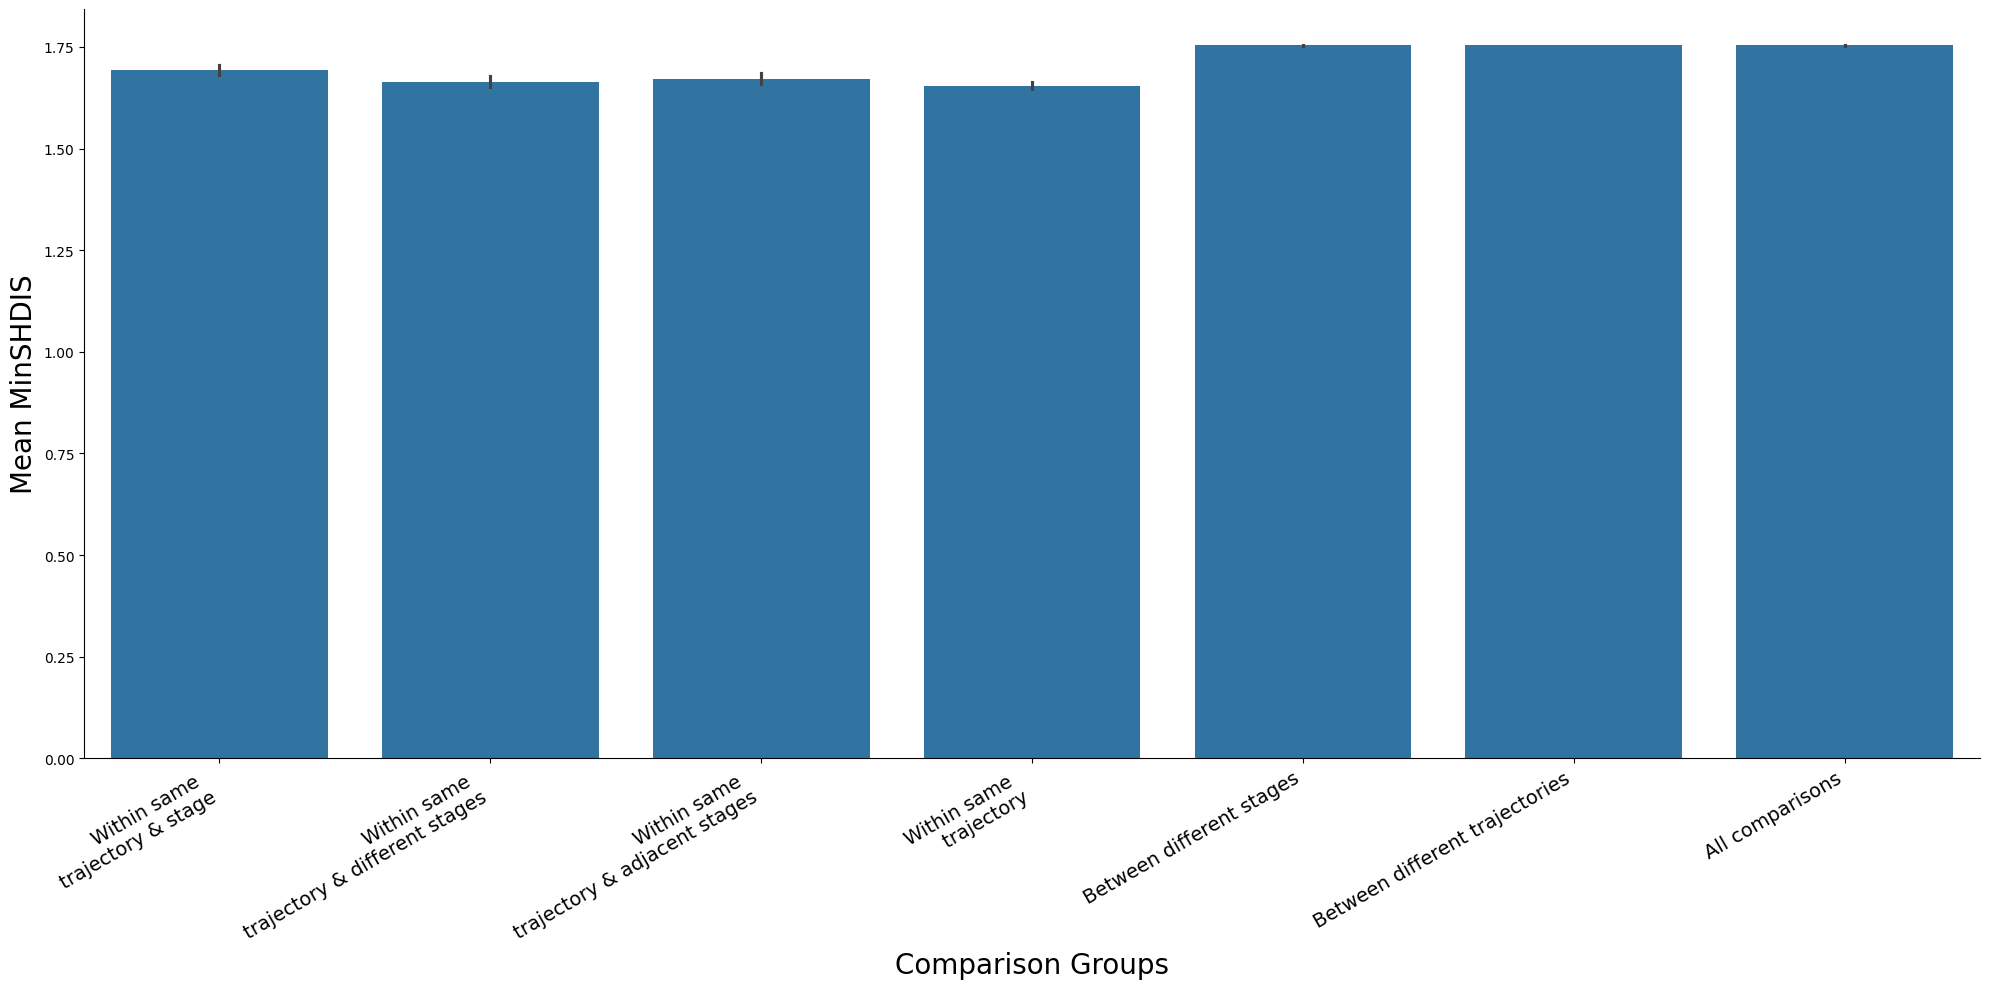

In [71]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_MinSHDIS_list,
    between_trj_time_MinSHDIS_list,
    between_trj_adjacent_time_MinSHDIS_list,
    same_trj_MinSHDIS_list,
    never_same_trj_time_MinSHDIS_list,
    never_same_trj_MinSHDIS_list,
    all_dispairs_MinSHDIS_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "MinSHDIS": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["MinSHDIS"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="MinSHDIS", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean MinSHDIS', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisMinSHDIS_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [72]:
# Initialize lists
within_trj_time_sep_list = []
between_trj_time_sep_list = []
between_trj_adjacent_time_sep_list = []
same_trj_sep_list = []
never_same_trj_time_sep_list = []
never_same_trj_sep_list = []

# All possible Jaccard indices
all_dispairs_sep_list = list(icd_genes_ppi_separation_dict.values())

# Prsepessing within trajectory comparisons
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_sep_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        within_dis_sep_set.add(disease_pair)
                        within_trj_time_sep_list.append(sep)

# Prsepessing between stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_sep_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        between_dis_sep_set.add(disease_pair)
                        between_trj_time_sep_list.append(sep)

# Prsepessing adjacent stages in the same trajectory
for trajectory, stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_sep_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        adjacent_dis_sep_set.add(disease_pair)
                        between_trj_adjacent_time_sep_list.append(sep)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in male_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, sep in icd_genes_ppi_separation_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_sep_list.append(sep)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, sep in icd_genes_ppi_separation_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_sep_list.append(sep)
    else:
        same_trj_sep_list.append(sep)


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3699399184.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


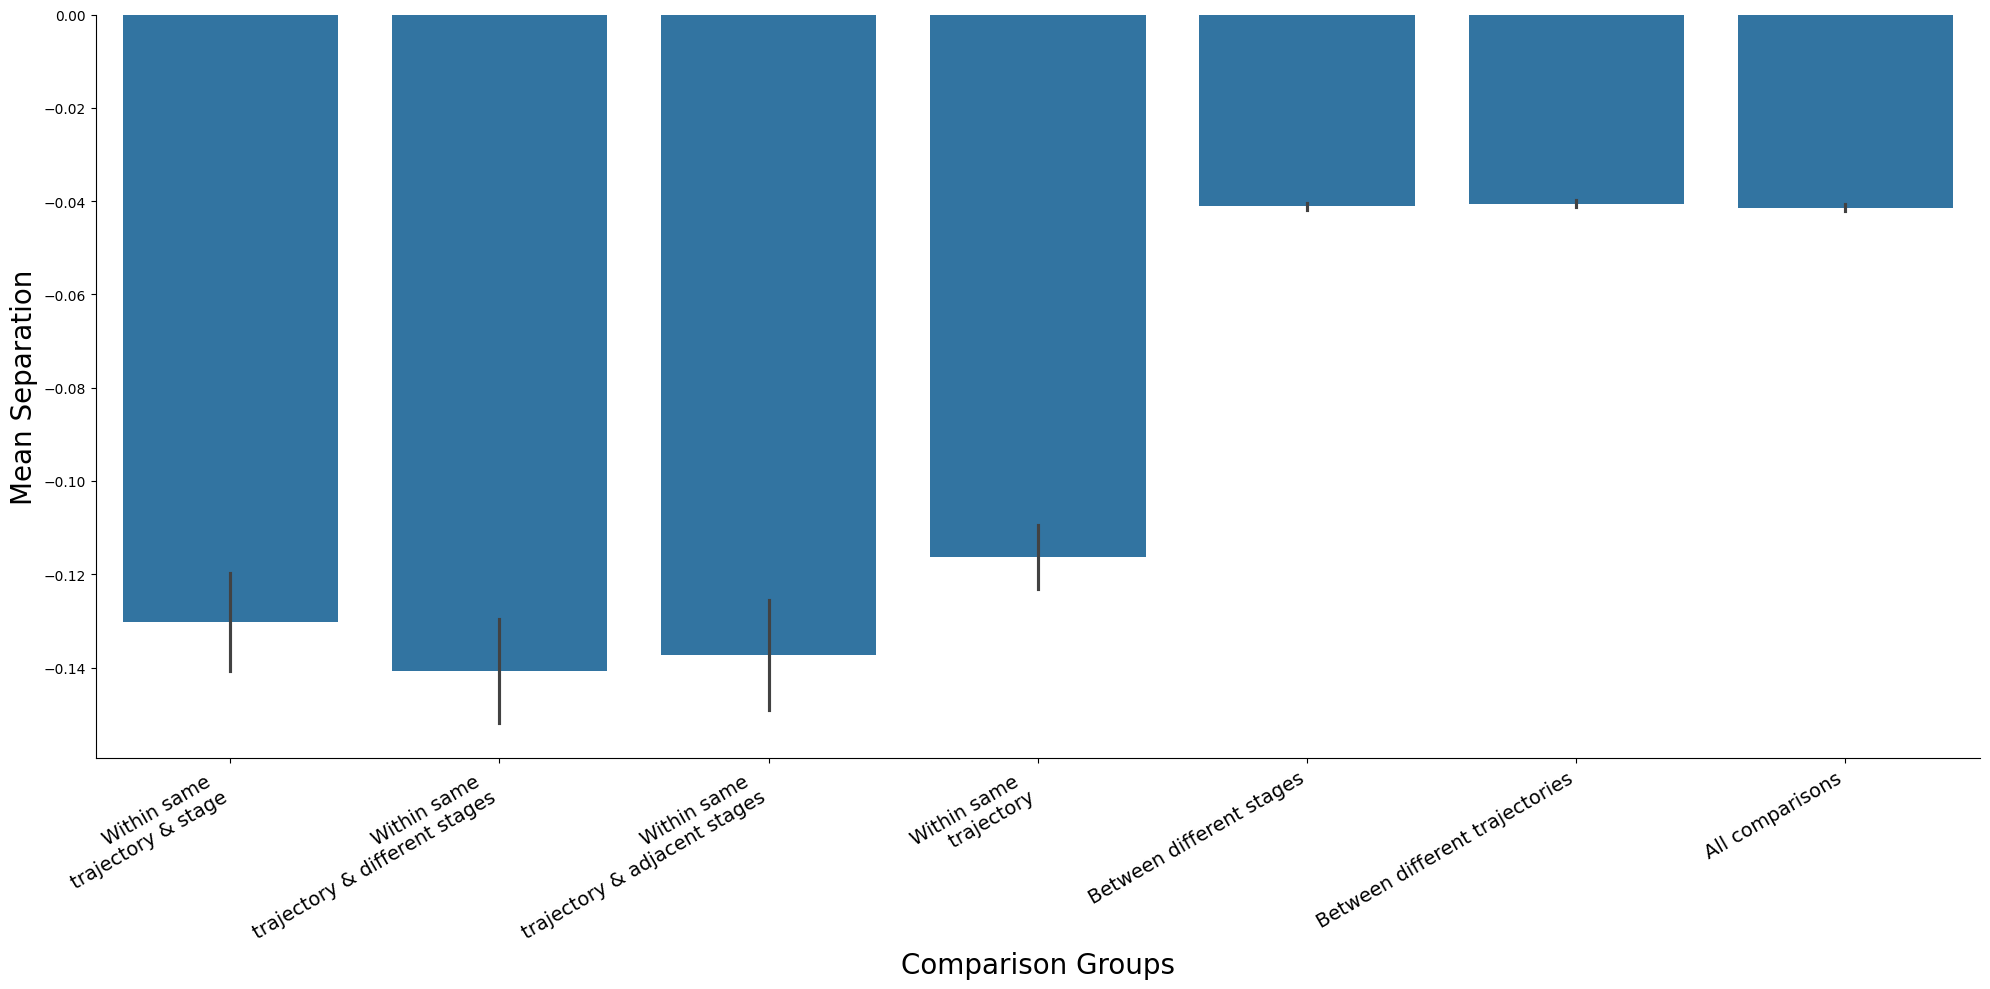

In [73]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_sep_list,
    between_trj_time_sep_list,
    between_trj_adjacent_time_sep_list,
    same_trj_sep_list,
    never_same_trj_time_sep_list,
    never_same_trj_sep_list,
    all_dispairs_sep_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Separation": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Separation"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Separation", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Separation', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisSeparation_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [ ]:
#Temporal resolution

In [74]:

# Calculating Jaccard indices for each temporal step
temporal_step1_ji = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_jaccard_dict, 1)
temporal_step2_ji = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_jaccard_dict, 2)
temporal_step3_ji = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_jaccard_dict, 3)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in male_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-occurring in the same trajectory and time
never_same_trj_time_ji_list = [
    ji for dispair, ji in icd_genes_ppi_overlap_jaccard_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-occurring in the same trajectory
never_same_trj_ji_list = [
    ji for dispair, ji in icd_genes_ppi_overlap_jaccard_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair Jaccard indices
all_dispairs_ji_list = list(icd_genes_ppi_overlap_jaccard_dict.values())


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3173191079.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


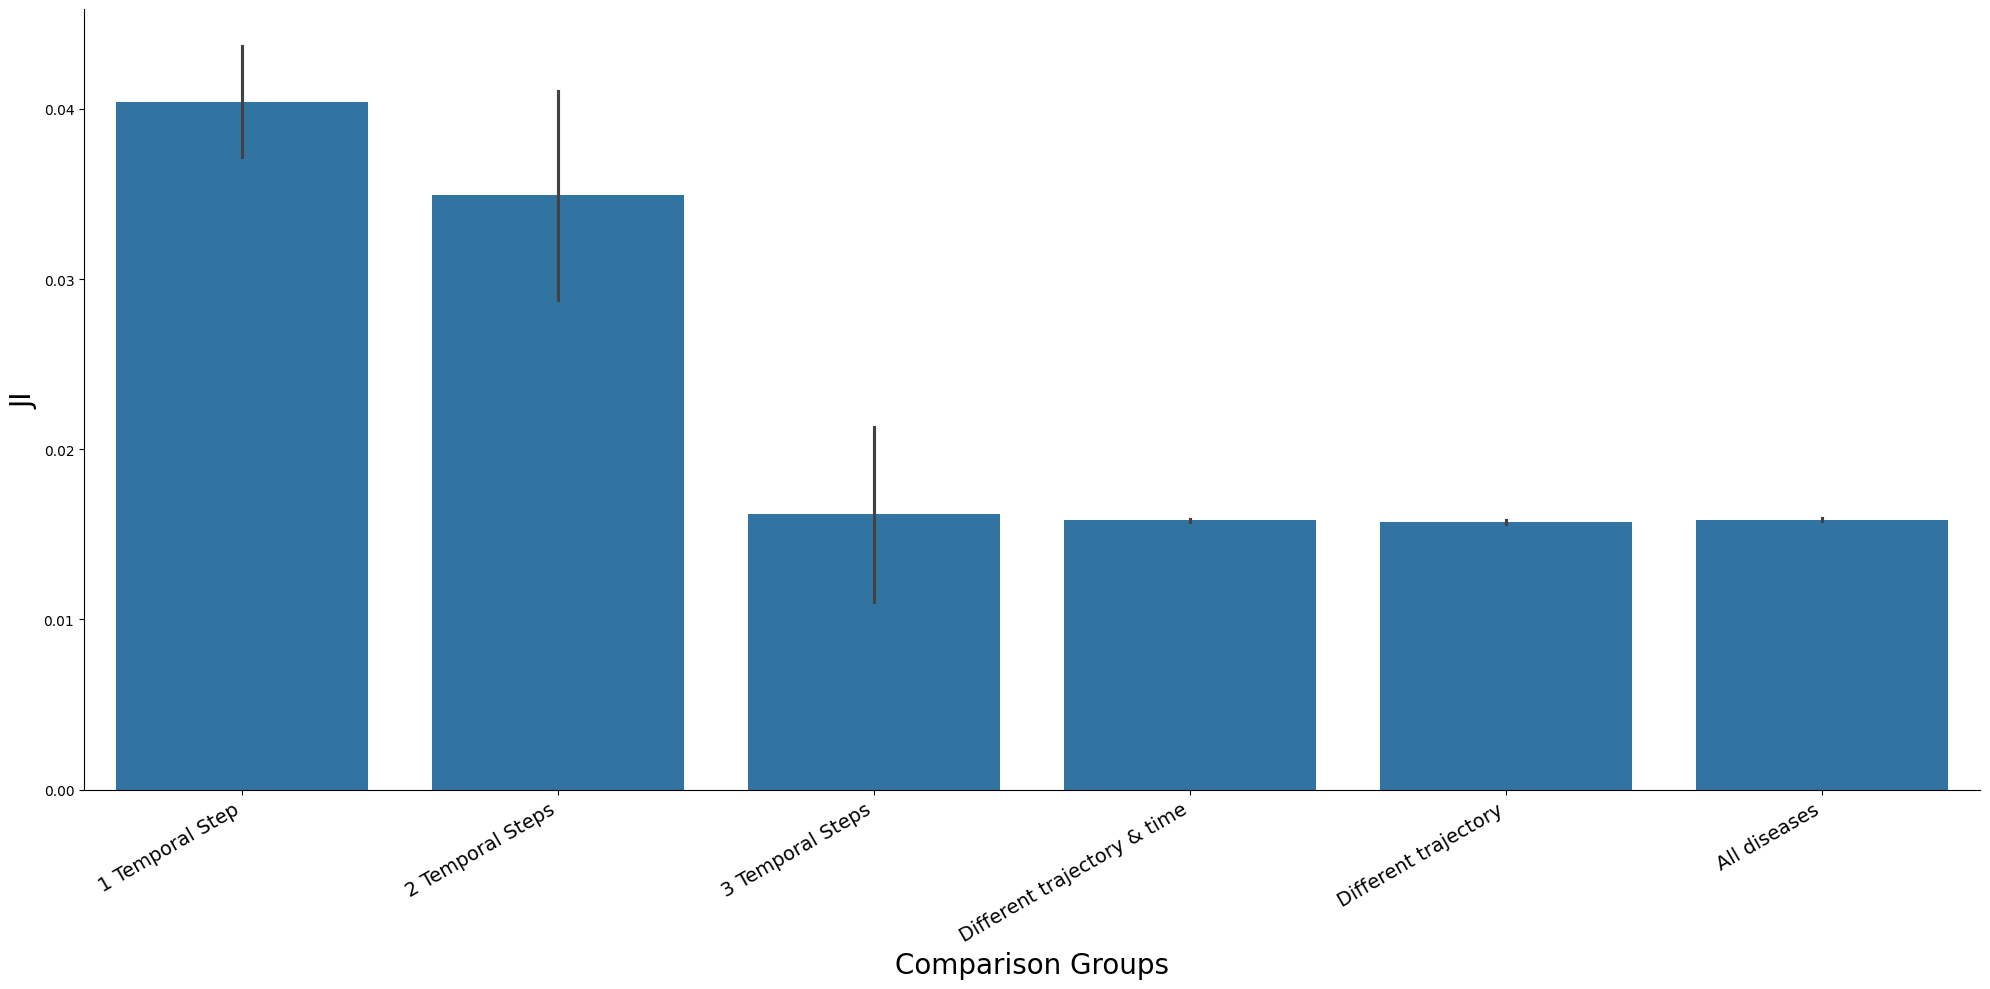

In [75]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        '3 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_ji,
    temporal_step2_ji,
    temporal_step3_ji,
    never_same_trj_time_ji_list,
    never_same_trj_ji_list,
    all_dispairs_ji_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "JI": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["JI"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="JI", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('JI', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisJI_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [76]:
# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_oc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_coefficient_dict, 1)
temporal_step2_oc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_coefficient_dict, 2)
temporal_step3_oc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_coefficient_dict, 3)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in male_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-occurring in the same trajectory and time
never_same_trj_time_oc_list = [
    oc for dispair, oc in icd_genes_ppi_overlap_coefficient_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-occurring in the same trajectory
never_same_trj_oc_list = [
    oc for dispair, oc in icd_genes_ppi_overlap_coefficient_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair OC indices
all_dispairs_oc_list = list(icd_genes_ppi_overlap_coefficient_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3527853188.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


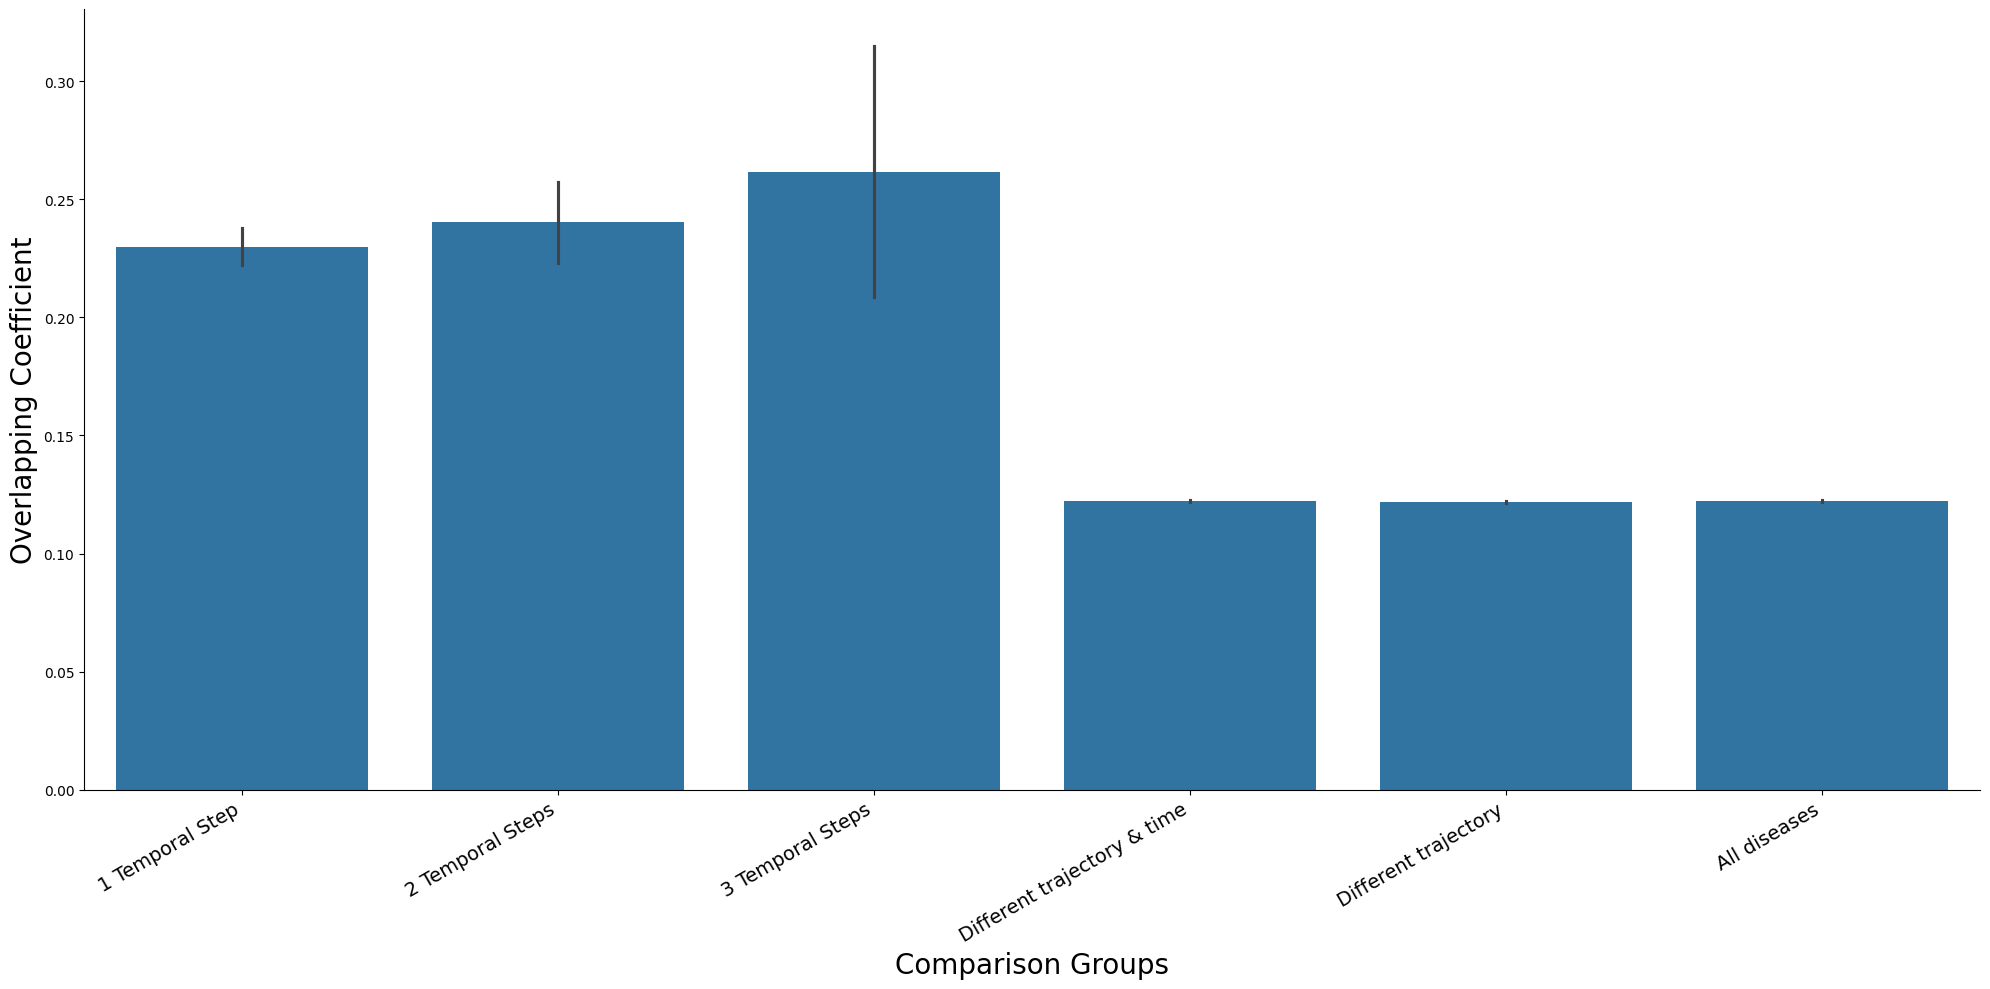

In [77]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        '3 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_oc,
    temporal_step2_oc,
    temporal_step3_oc,
    never_same_trj_time_oc_list,
    never_same_trj_oc_list,
    all_dispairs_oc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "OC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["OC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="OC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Overlapping Coefficient', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisOC_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [78]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_aspdc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_aspdc_dict, 1)
temporal_step2_aspdc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_aspdc_dict, 2)
temporal_step3_aspdc = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_aspdc_dict, 3)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in male_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-aspdccurring in the same trajectory and time
never_same_trj_time_aspdc_list = [
    aspdc for dispair, aspdc in icd_genes_ppi_aspdc_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-aspdccurring in the same trajectory
never_same_trj_aspdc_list = [
    aspdc for dispair, aspdc in icd_genes_ppi_aspdc_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair ASPDC indices
all_dispairs_aspdc_list = list(icd_genes_ppi_aspdc_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3661039646.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


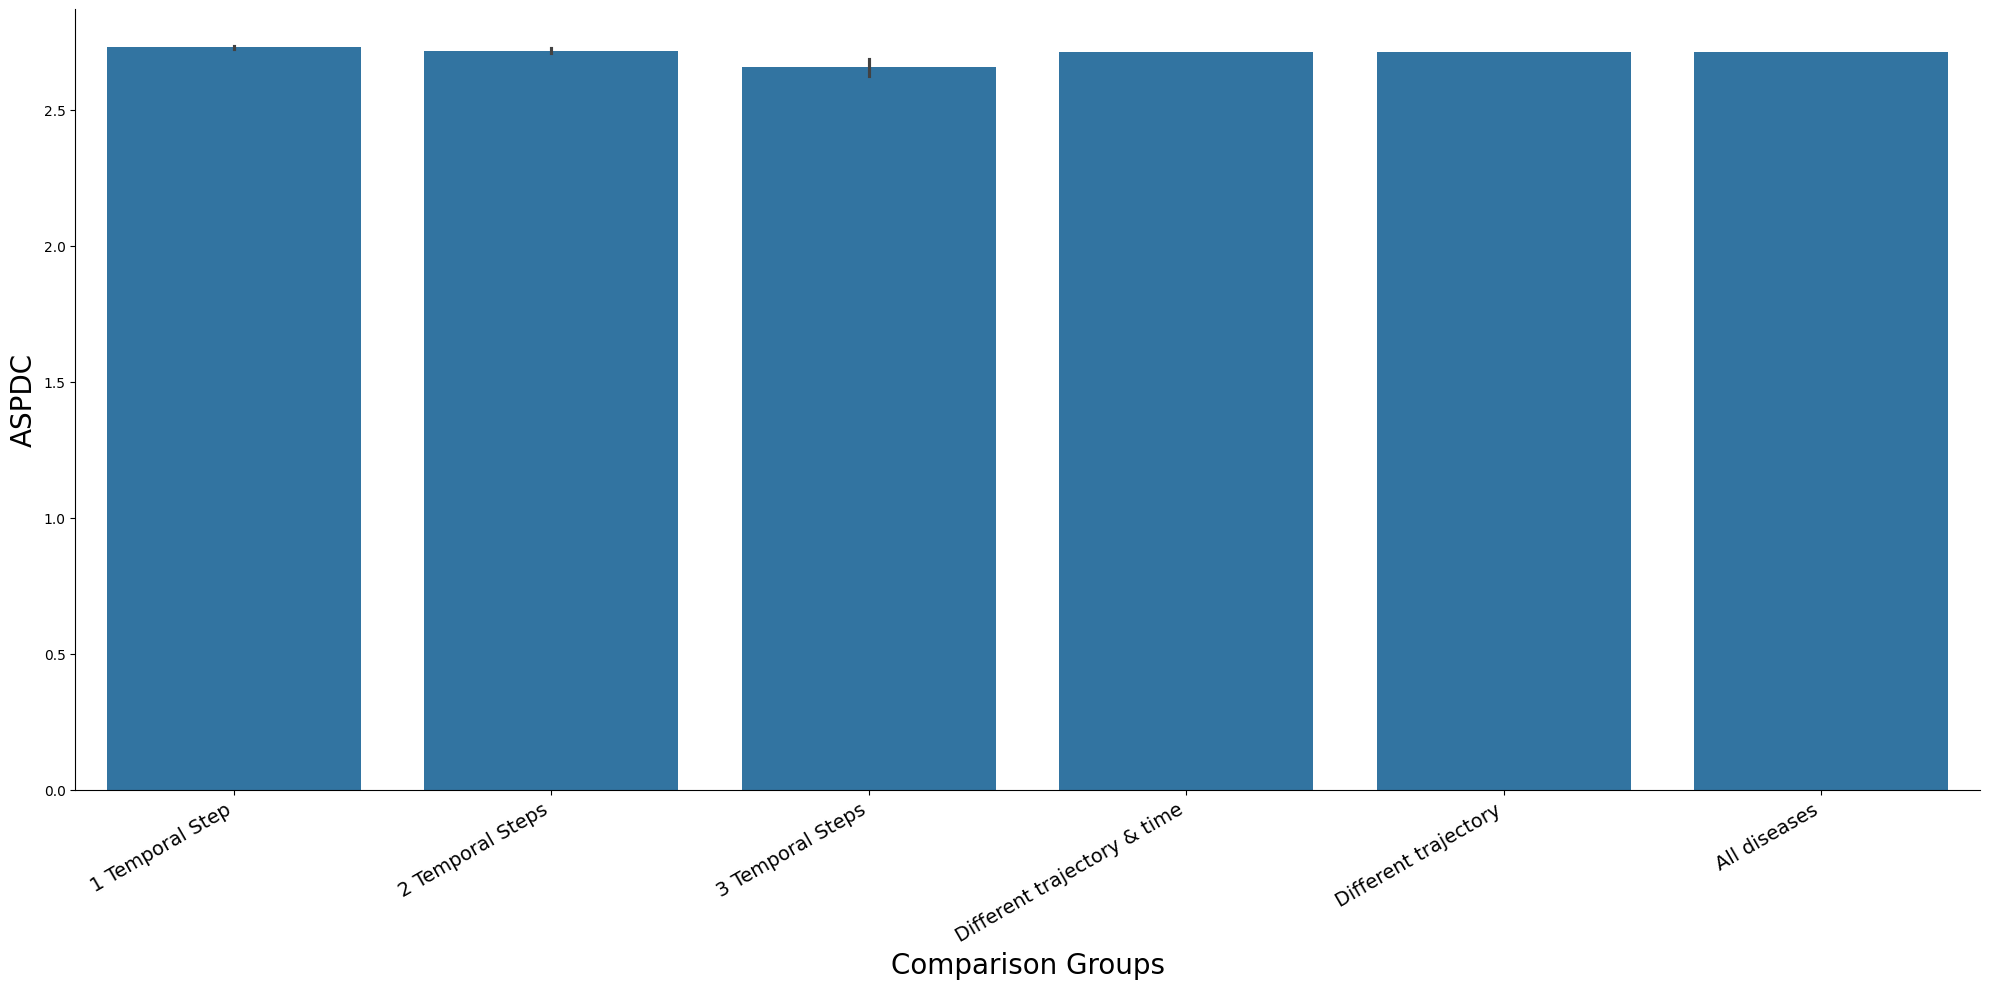

In [79]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        '3 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_aspdc,
    temporal_step2_aspdc,
    temporal_step3_aspdc,
    never_same_trj_time_aspdc_list,
    never_same_trj_aspdc_list,
    all_dispairs_aspdc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "ASPDC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["ASPDC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="ASPDC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('ASPDC', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisASPDC_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [80]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_MinSHDis = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_mean_shortest_distance_dict, 1)
temporal_step2_MinSHDis = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_mean_shortest_distance_dict, 2)
temporal_step3_MinSHDis = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_mean_shortest_distance_dict, 3)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in male_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-MinSHDiscurring in the same trajectory and time
never_same_trj_time_MinSHDis_list = [
    MinSHDis for dispair, MinSHDis in icd_genes_ppi_mean_shortest_distance_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-MinSHDiscurring in the same trajectory
never_same_trj_MinSHDis_list = [
    MinSHDis for dispair, MinSHDis in icd_genes_ppi_mean_shortest_distance_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair MinSHDis indices
all_dispairs_MinSHDis_list = list(icd_genes_ppi_mean_shortest_distance_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3101491388.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


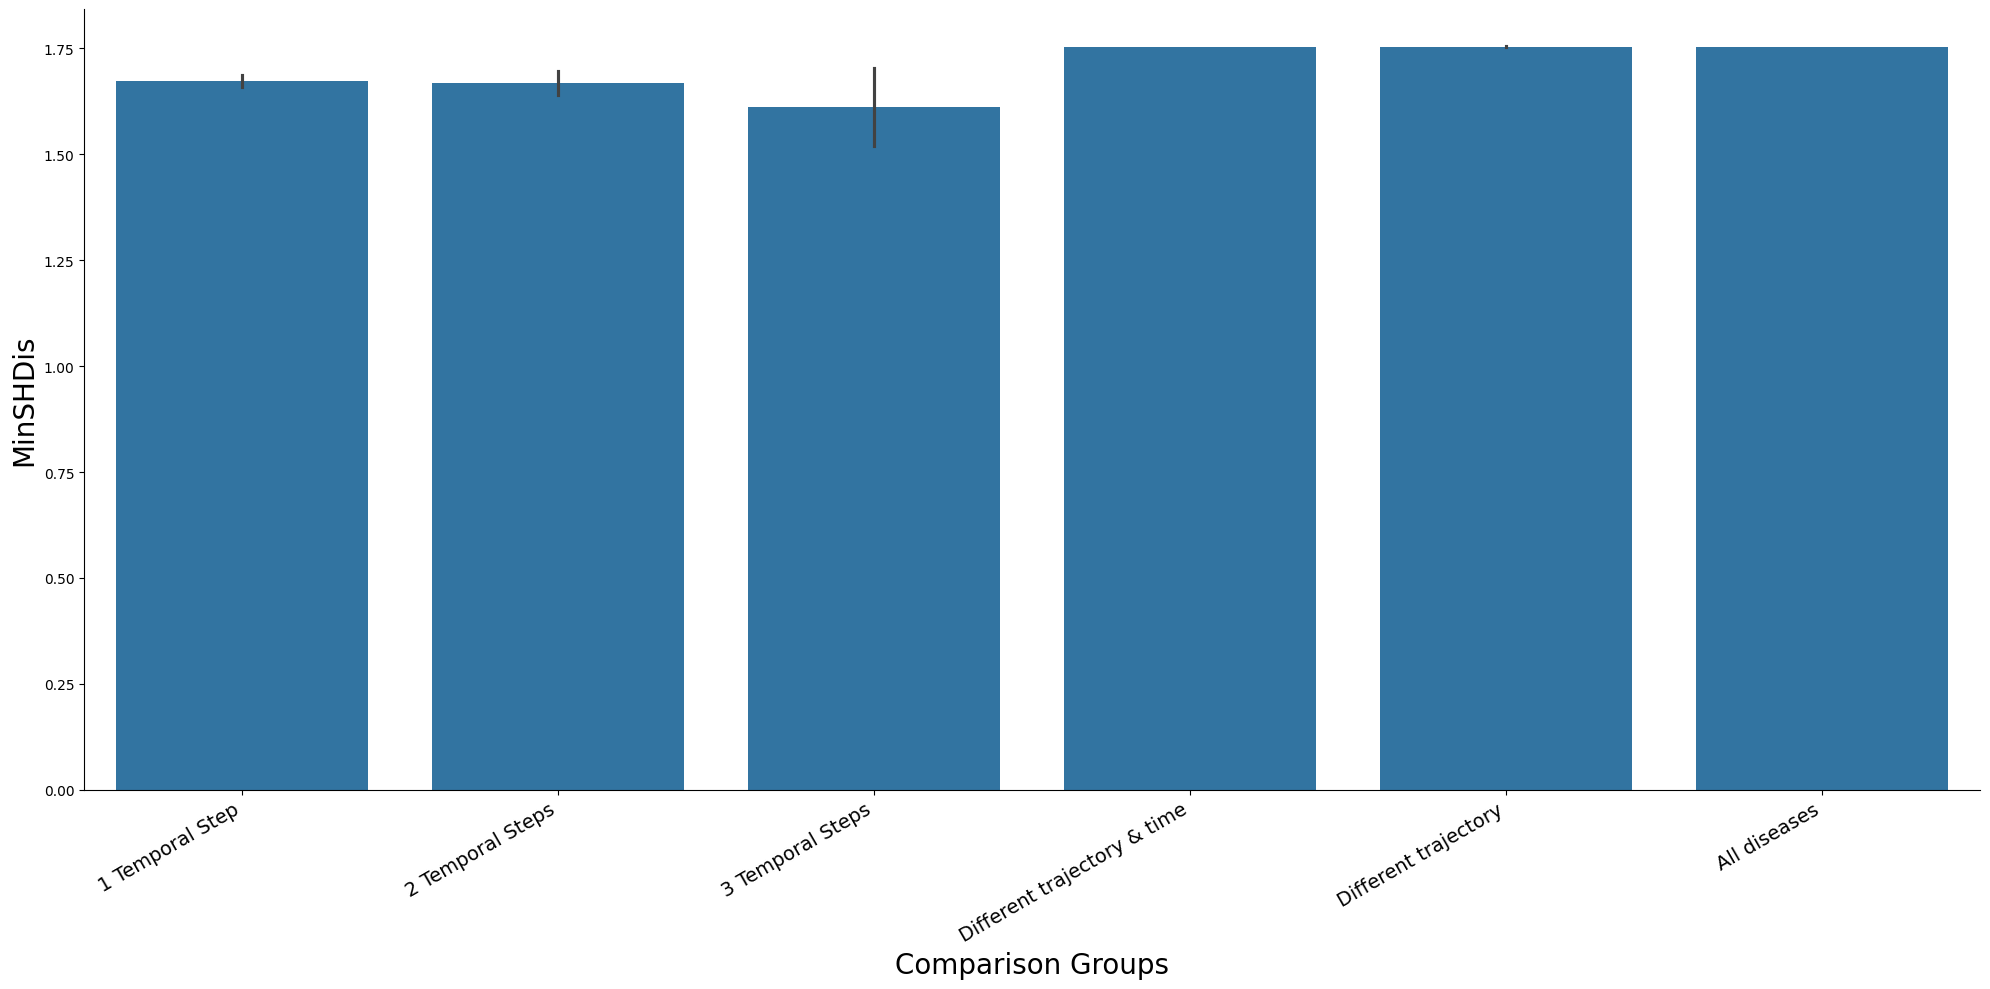

In [81]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        '3 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_MinSHDis,
    temporal_step2_MinSHDis,
    temporal_step3_MinSHDis,
    never_same_trj_time_MinSHDis_list,
    never_same_trj_MinSHDis_list,
    all_dispairs_MinSHDis_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "MinSHDis": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["MinSHDis"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="MinSHDis", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('MinSHDis', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisMinSHDis_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [82]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_sep = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_separation_dict, 1)
temporal_step2_sep = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_separation_dict, 2)
temporal_step3_sep = calculate_temporal_distance(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_separation_dict, 3)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in male_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-sepcurring in the same trajectory and time
never_same_trj_time_sep_list = [
    sep for dispair, sep in icd_genes_ppi_separation_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-sepcurring in the same trajectory
never_same_trj_sep_list = [
    sep for dispair, sep in icd_genes_ppi_separation_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair separation indices
all_dispairs_sep_list = list(icd_genes_ppi_separation_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/1002742401.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


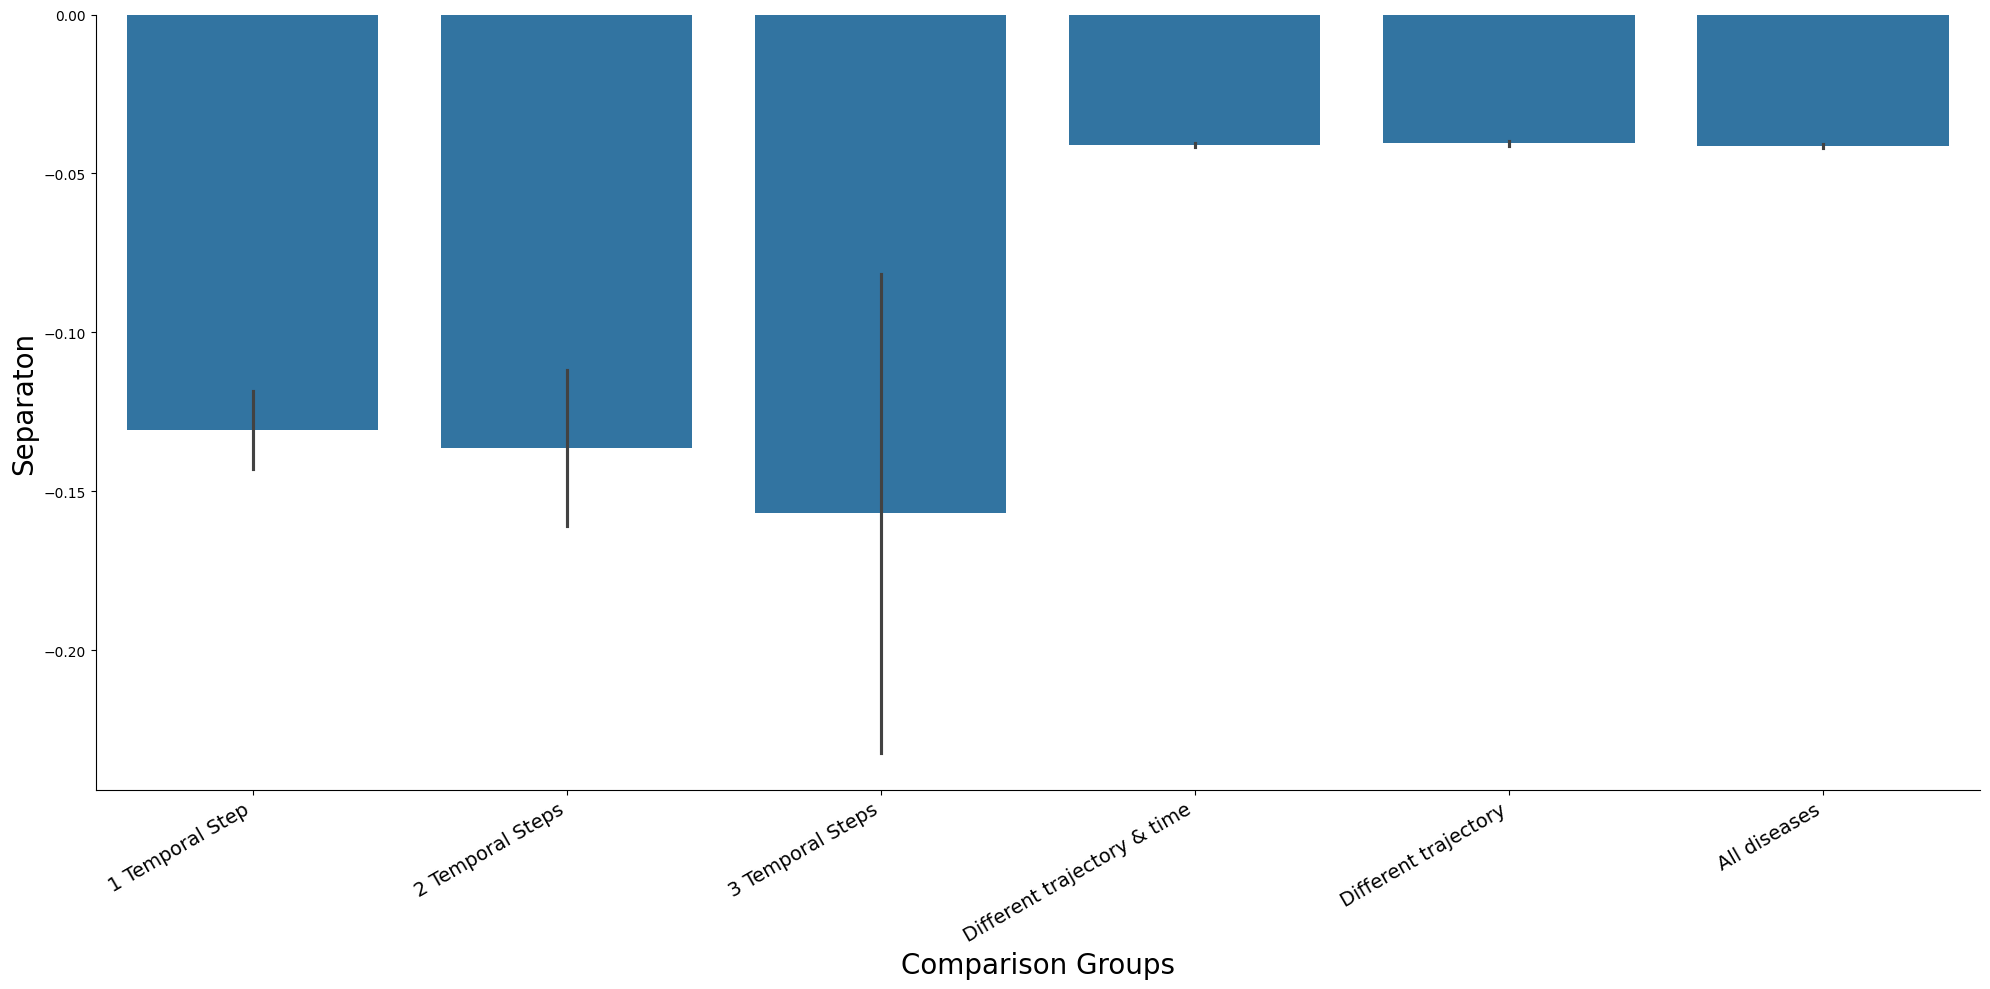

In [83]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        '3 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_sep,
    temporal_step2_sep,
    temporal_step3_sep,
    never_same_trj_time_sep_list,
    never_same_trj_sep_list,
    all_dispairs_sep_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Separaton": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Separaton"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Separaton", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Separaton', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisSeparaton_Male.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

## FEMALES

In [86]:
# Initialize lists
within_trj_time_ji_list = []
between_trj_time_ji_list = []
between_trj_adjacent_time_ji_list = []
same_trj_ji_list = []
never_same_trj_time_ji_list = []
never_same_trj_ji_list = []

# All possible Jaccard indices
all_dispairs_ji_list = list(icd_genes_ppi_overlap_jaccard_dict.values())

# Processing within trajectory comparisons
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_ji_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        within_dis_ji_set.add(disease_pair)
                        within_trj_time_ji_list.append(ji)

# Processing between stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_ji_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        between_dis_ji_set.add(disease_pair)
                        between_trj_time_ji_list.append(ji)

# Processing adjacent stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_ji_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_ji_set:
                    ji = get_distance_index(disease_pair, icd_genes_ppi_overlap_jaccard_dict)
                    if ji is not None:
                        adjacent_dis_ji_set.add(disease_pair)
                        between_trj_adjacent_time_ji_list.append(ji)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in female_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, ji in icd_genes_ppi_overlap_jaccard_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_ji_list.append(ji)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, ji in icd_genes_ppi_overlap_jaccard_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_ji_list.append(ji)
    else:
        same_trj_ji_list.append(ji)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/2473861009.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


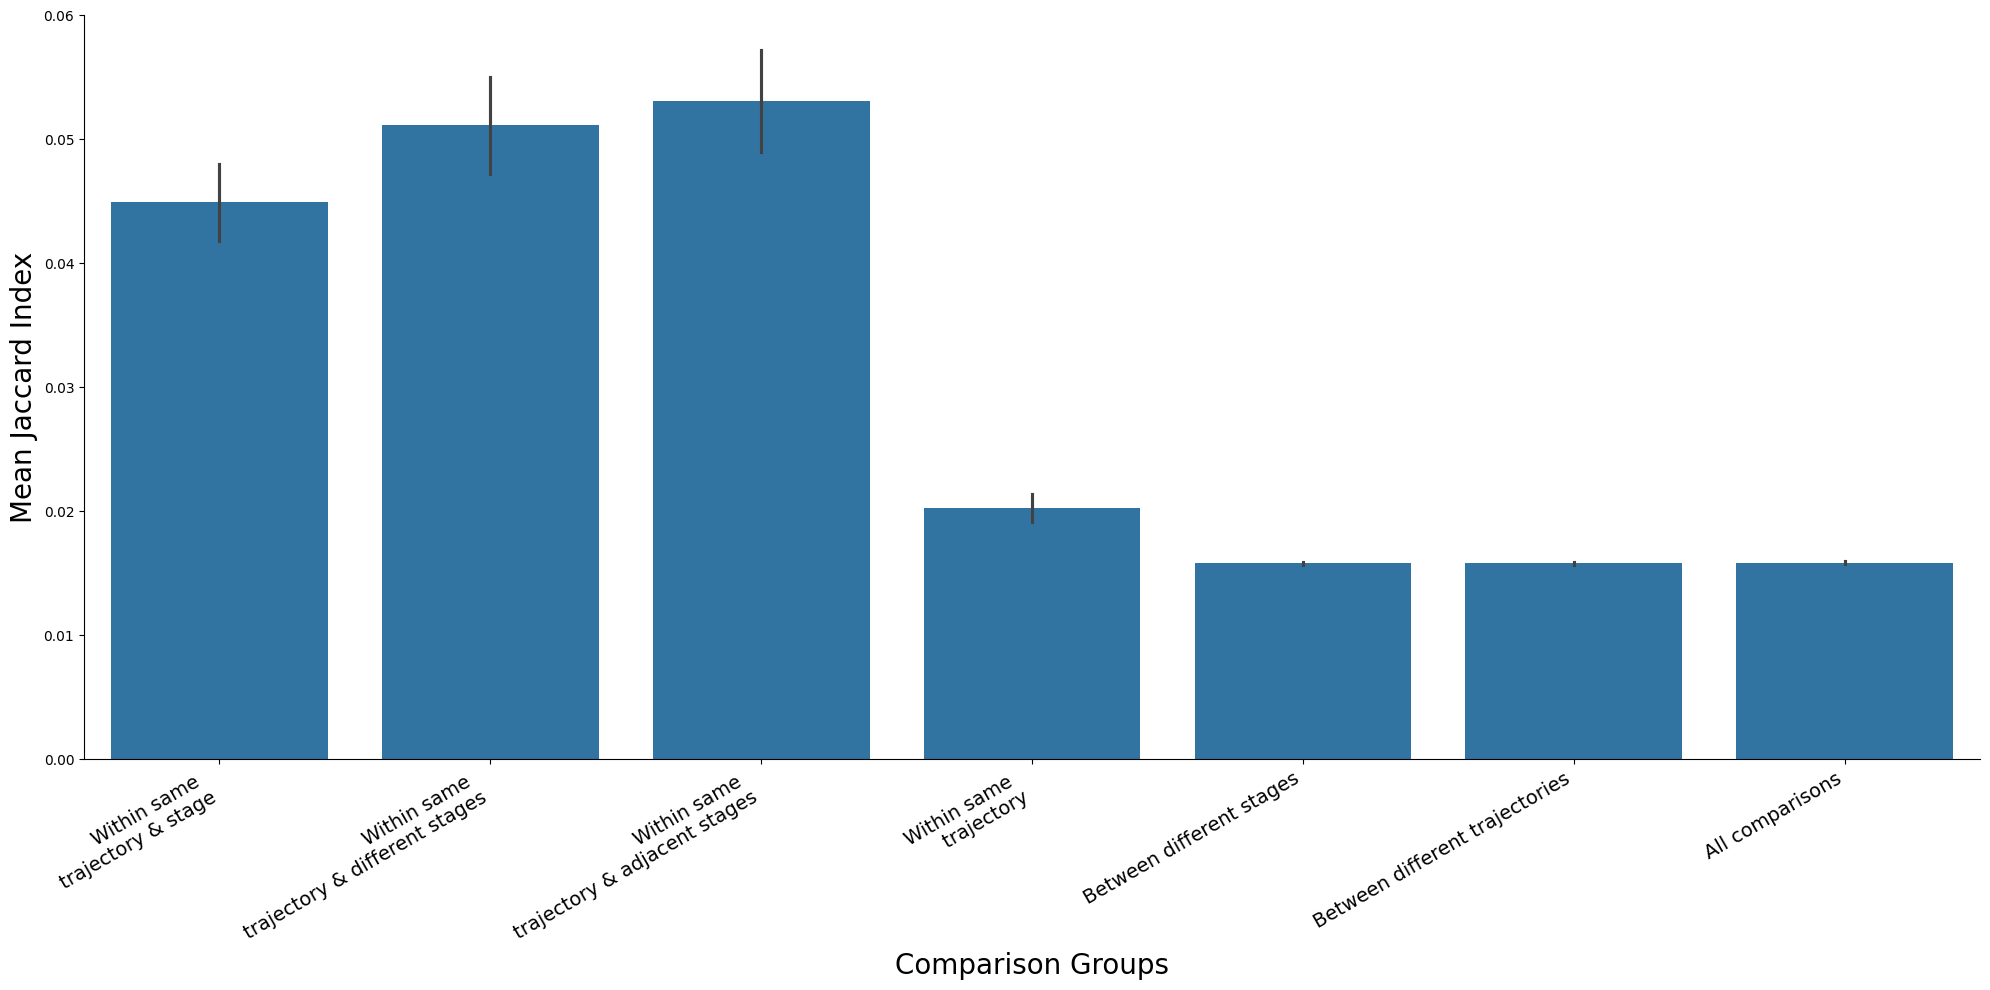

In [87]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_ji_list,
    between_trj_time_ji_list,
    between_trj_adjacent_time_ji_list,
    same_trj_ji_list,
    never_same_trj_time_ji_list,
    never_same_trj_ji_list,
    all_dispairs_ji_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Jaccard Index": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Jaccard Index"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Jaccard Index", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Jaccard Index', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisJI_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [88]:

# Initialize lists
within_trj_time_oc_list = []
between_trj_time_oc_list = []
between_trj_adjacent_time_oc_list = []
same_trj_oc_list = []
never_same_trj_time_oc_list = []
never_same_trj_oc_list = []

# All possible Jaccard indices
all_dispairs_oc_list = list(icd_genes_ppi_overlap_coefficient_dict.values())

# Processing within trajectory comparisons
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_oc_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        within_dis_oc_set.add(disease_pair)
                        within_trj_time_oc_list.append(oc)

# Processing between stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_oc_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        between_dis_oc_set.add(disease_pair)
                        between_trj_time_oc_list.append(oc)

# Processing adjacent stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_oc_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_oc_set:
                    oc = get_distance_index(disease_pair, icd_genes_ppi_overlap_coefficient_dict)
                    if oc is not None:
                        adjacent_dis_oc_set.add(disease_pair)
                        between_trj_adjacent_time_oc_list.append(oc)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in female_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, oc in icd_genes_ppi_overlap_coefficient_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_oc_list.append(oc)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, oc in icd_genes_ppi_overlap_coefficient_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_oc_list.append(oc)
    else:
        same_trj_oc_list.append(oc)



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3760346521.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


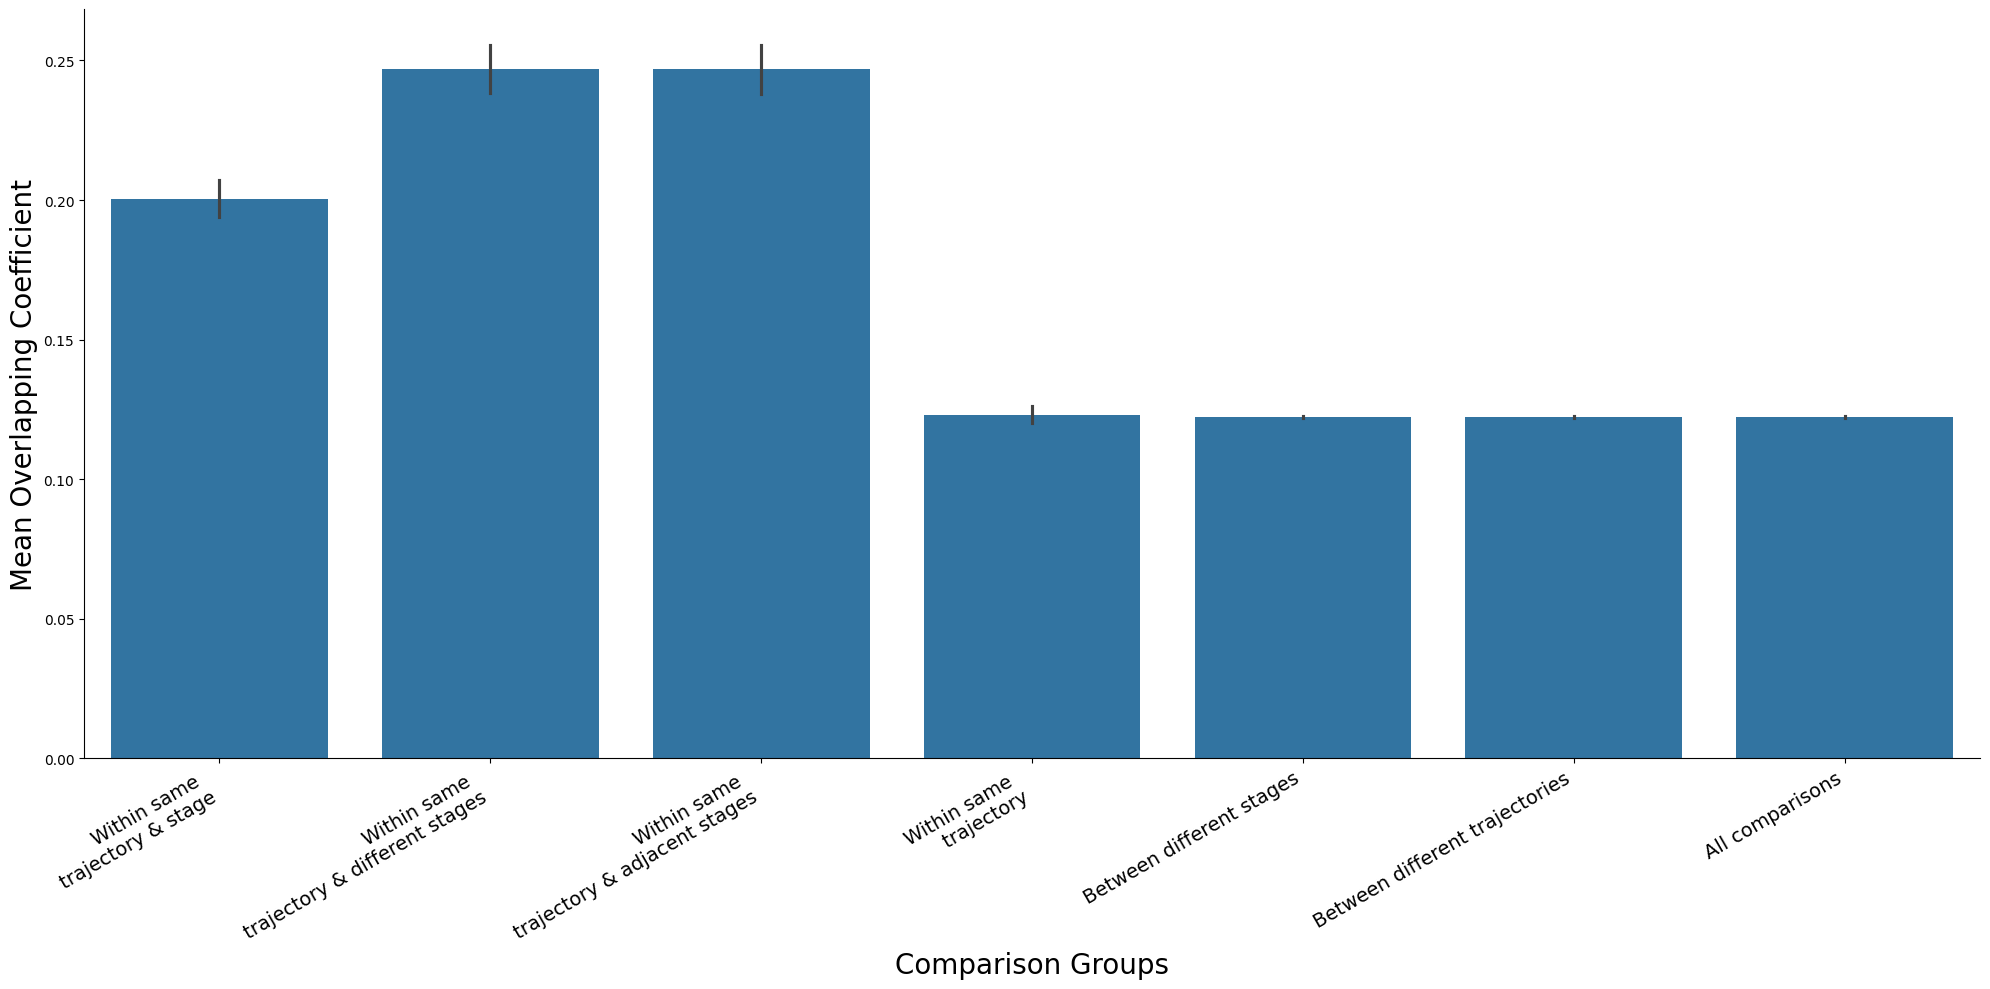

In [89]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_oc_list,
    between_trj_time_oc_list,
    between_trj_adjacent_time_oc_list,
    same_trj_oc_list,
    never_same_trj_time_oc_list,
    never_same_trj_oc_list,
    all_dispairs_oc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Overlapping Coefficient": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Overlapping Coefficient"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Overlapping Coefficient", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Overlapping Coefficient', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisOC_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [90]:

# Initialize lists
within_trj_time_aspdc_list = []
between_trj_time_aspdc_list = []
between_trj_adjacent_time_aspdc_list = []
same_trj_aspdc_list = []
never_same_trj_time_aspdc_list = []
never_same_trj_aspdc_list = []

# All possible Jaccard indices
all_dispairs_aspdc_list = list(icd_genes_ppi_aspdc_dict.values())

# Praspdcessing within trajectory comparisons
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_aspdc_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        within_dis_aspdc_set.add(disease_pair)
                        within_trj_time_aspdc_list.append(aspdc)

# Praspdcessing between stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_aspdc_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        between_dis_aspdc_set.add(disease_pair)
                        between_trj_time_aspdc_list.append(aspdc)

# Praspdcessing adjacent stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_aspdc_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_aspdc_set:
                    aspdc = get_distance_index(disease_pair, icd_genes_ppi_aspdc_dict)
                    if aspdc is not None:
                        adjacent_dis_aspdc_set.add(disease_pair)
                        between_trj_adjacent_time_aspdc_list.append(aspdc)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in female_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, aspdc in icd_genes_ppi_aspdc_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_aspdc_list.append(aspdc)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, aspdc in icd_genes_ppi_aspdc_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_aspdc_list.append(aspdc)
    else:
        same_trj_aspdc_list.append(aspdc)



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/1178740857.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


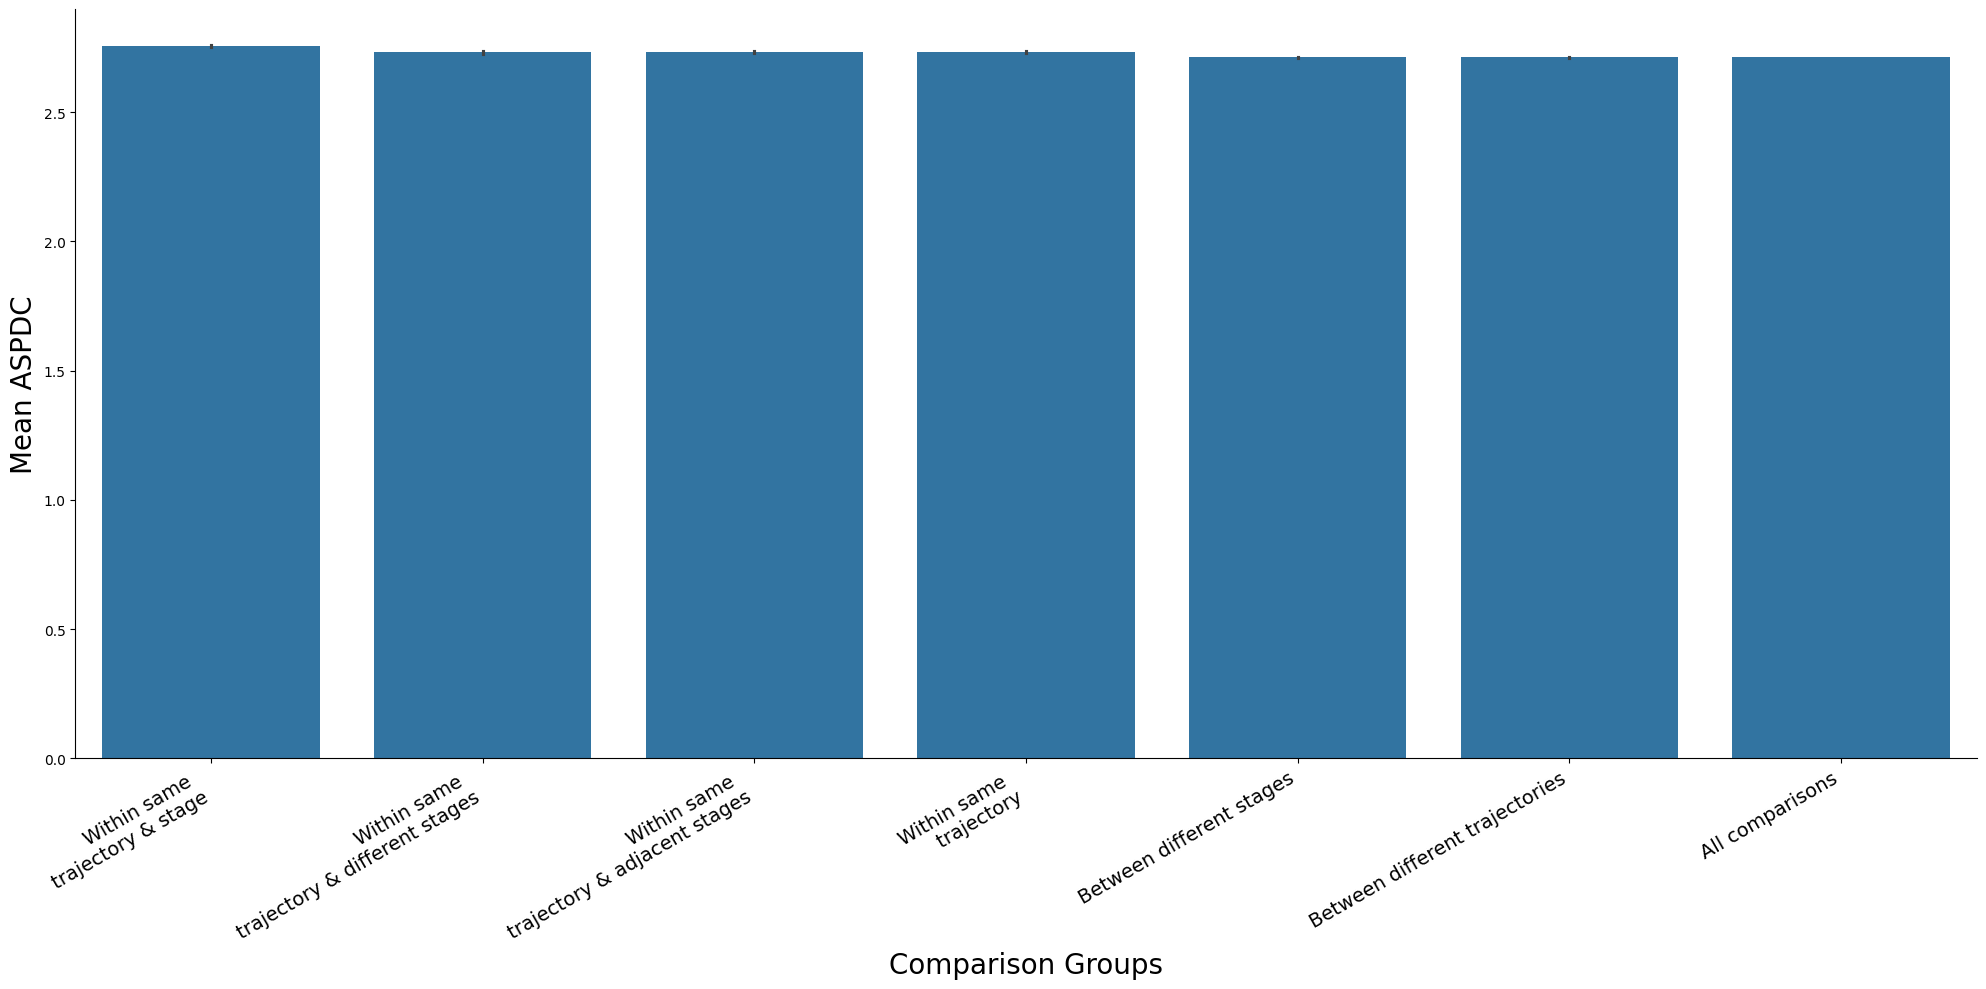

In [91]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_aspdc_list,
    between_trj_time_aspdc_list,
    between_trj_adjacent_time_aspdc_list,
    same_trj_aspdc_list,
    never_same_trj_time_aspdc_list,
    never_same_trj_aspdc_list,
    all_dispairs_aspdc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "ASPDC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["ASPDC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="ASPDC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean ASPDC', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisASPDC_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [92]:
# Initialize lists
within_trj_time_MinSHDIS_list = []
between_trj_time_MinSHDIS_list = []
between_trj_adjacent_time_MinSHDIS_list = []
same_trj_MinSHDIS_list = []
never_same_trj_time_MinSHDIS_list = []
never_same_trj_MinSHDIS_list = []

# All possible Jaccard indices
all_dispairs_MinSHDIS_list = list(icd_genes_ppi_mean_shortest_distance_dict.values())

# PrMinSHDISessing within trajectory comparisons
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_MinSHDIS_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        within_dis_MinSHDIS_set.add(disease_pair)
                        within_trj_time_MinSHDIS_list.append(MinSHDIS)

# PrMinSHDISessing between stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_MinSHDIS_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        between_dis_MinSHDIS_set.add(disease_pair)
                        between_trj_time_MinSHDIS_list.append(MinSHDIS)

# PrMinSHDISessing adjacent stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_MinSHDIS_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_MinSHDIS_set:
                    MinSHDIS = get_distance_index(disease_pair, icd_genes_ppi_mean_shortest_distance_dict)
                    if MinSHDIS is not None:
                        adjacent_dis_MinSHDIS_set.add(disease_pair)
                        between_trj_adjacent_time_MinSHDIS_list.append(MinSHDIS)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in female_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, MinSHDIS in icd_genes_ppi_mean_shortest_distance_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_MinSHDIS_list.append(MinSHDIS)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, MinSHDIS in icd_genes_ppi_mean_shortest_distance_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_MinSHDIS_list.append(MinSHDIS)
    else:
        same_trj_MinSHDIS_list.append(MinSHDIS)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/2344878946.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


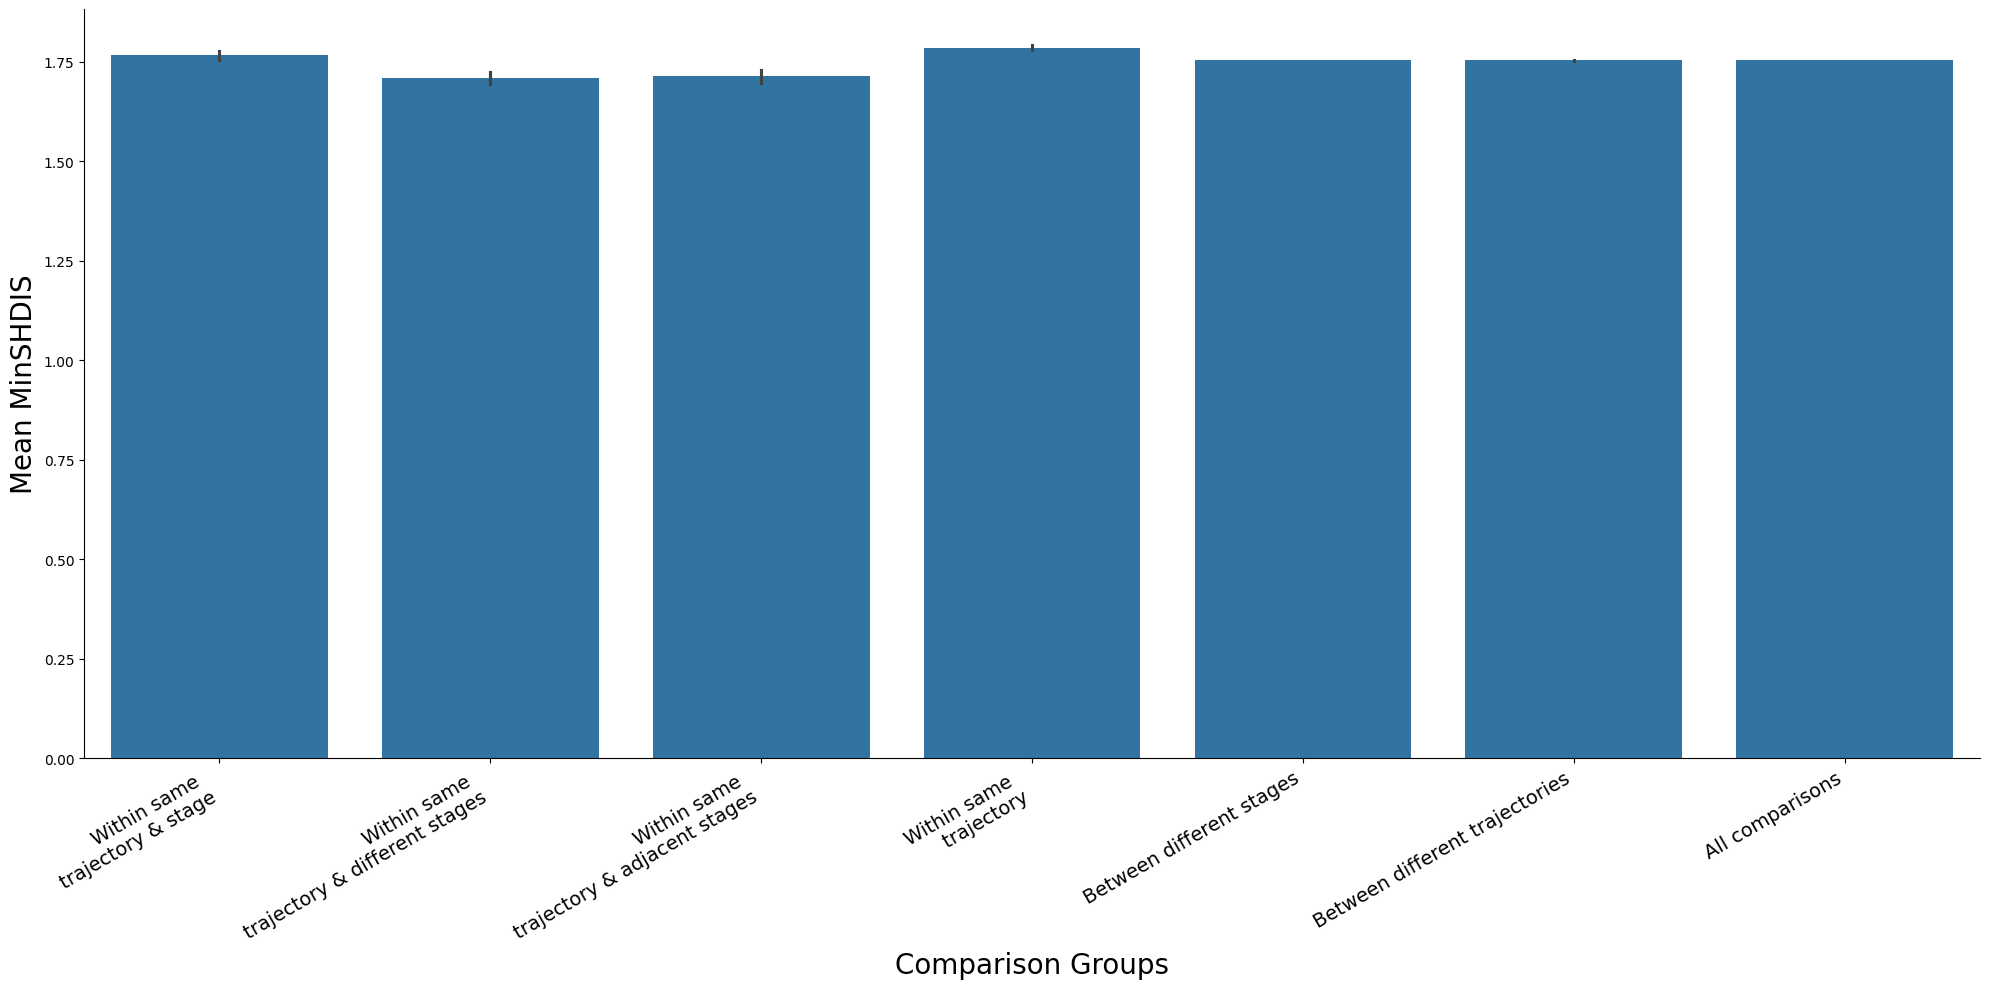

In [93]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_MinSHDIS_list,
    between_trj_time_MinSHDIS_list,
    between_trj_adjacent_time_MinSHDIS_list,
    same_trj_MinSHDIS_list,
    never_same_trj_time_MinSHDIS_list,
    never_same_trj_MinSHDIS_list,
    all_dispairs_MinSHDIS_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "MinSHDIS": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["MinSHDIS"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="MinSHDIS", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean MinSHDIS', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisMinSHDIS_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [94]:
# Initialize lists
within_trj_time_sep_list = []
between_trj_time_sep_list = []
between_trj_adjacent_time_sep_list = []
same_trj_sep_list = []
never_same_trj_time_sep_list = []
never_same_trj_sep_list = []

# All possible Jaccard indices
all_dispairs_sep_list = list(icd_genes_ppi_separation_dict.values())

# Prsepessing within trajectory comparisons
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    within_dis_sep_set = set()
    
    for stage, disease_list in stage_dict.items():
        if len(disease_list) > 1:
            for disease_pair in generate_unique_pairs(disease_list):
                if disease_pair not in within_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        within_dis_sep_set.add(disease_pair)
                        within_trj_time_sep_list.append(sep)

# Prsepessing between stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    between_dis_sep_set = set()
    stages = list(stage_dict.keys())
    
    for s1, s2 in it.combinations(stages, 2):
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in between_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        between_dis_sep_set.add(disease_pair)
                        between_trj_time_sep_list.append(sep)

# Prsepessing adjacent stages in the same trajectory
for trajectory, stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    adjacent_dis_sep_set = set()
    stages = sorted(stage_dict.keys())
    
    for i in range(len(stages) - 1):
        s1, s2 = stages[i], stages[i + 1]
        diseases_stage1 = stage_dict[s1]
        diseases_stage2 = stage_dict[s2]
        
        for d1 in diseases_stage1:
            for d2 in diseases_stage2:
                disease_pair = (d1, d2)
                if disease_pair not in adjacent_dis_sep_set:
                    sep = get_distance_index(disease_pair, icd_genes_ppi_separation_dict)
                    if sep is not None:
                        adjacent_dis_sep_set.add(disease_pair)
                        between_trj_adjacent_time_sep_list.append(sep)

# Collecting disease pairs within trajectories for comparison
dis_combinations_among_trj_time_set = set()
for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values():
    for disease_list in stage_dict.values():
        if len(disease_list) > 1:
            dis_combinations_among_trj_time_set.update(generate_unique_pairs(disease_list))

# Collecting disease pairs within all trajectories
dis_combinations_among_trj_set = set()
for disease_list in female_trajectories_dict_filtered.values():
    dis_combinations_among_trj_set.update(generate_unique_pairs(disease_list))

# Identifying diseases never appearing together in the same stage
for disease_pair, sep in icd_genes_ppi_separation_dict.items():
    if disease_pair not in dis_combinations_among_trj_time_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_time_set:
        never_same_trj_time_sep_list.append(sep)

# Identifying diseases never appearing together in the same trajectory
for disease_pair, sep in icd_genes_ppi_separation_dict.items():
    if disease_pair not in dis_combinations_among_trj_set and (disease_pair[1], disease_pair[0]) not in dis_combinations_among_trj_set:
        never_same_trj_sep_list.append(sep)
    else:
        same_trj_sep_list.append(sep)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3310094686.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


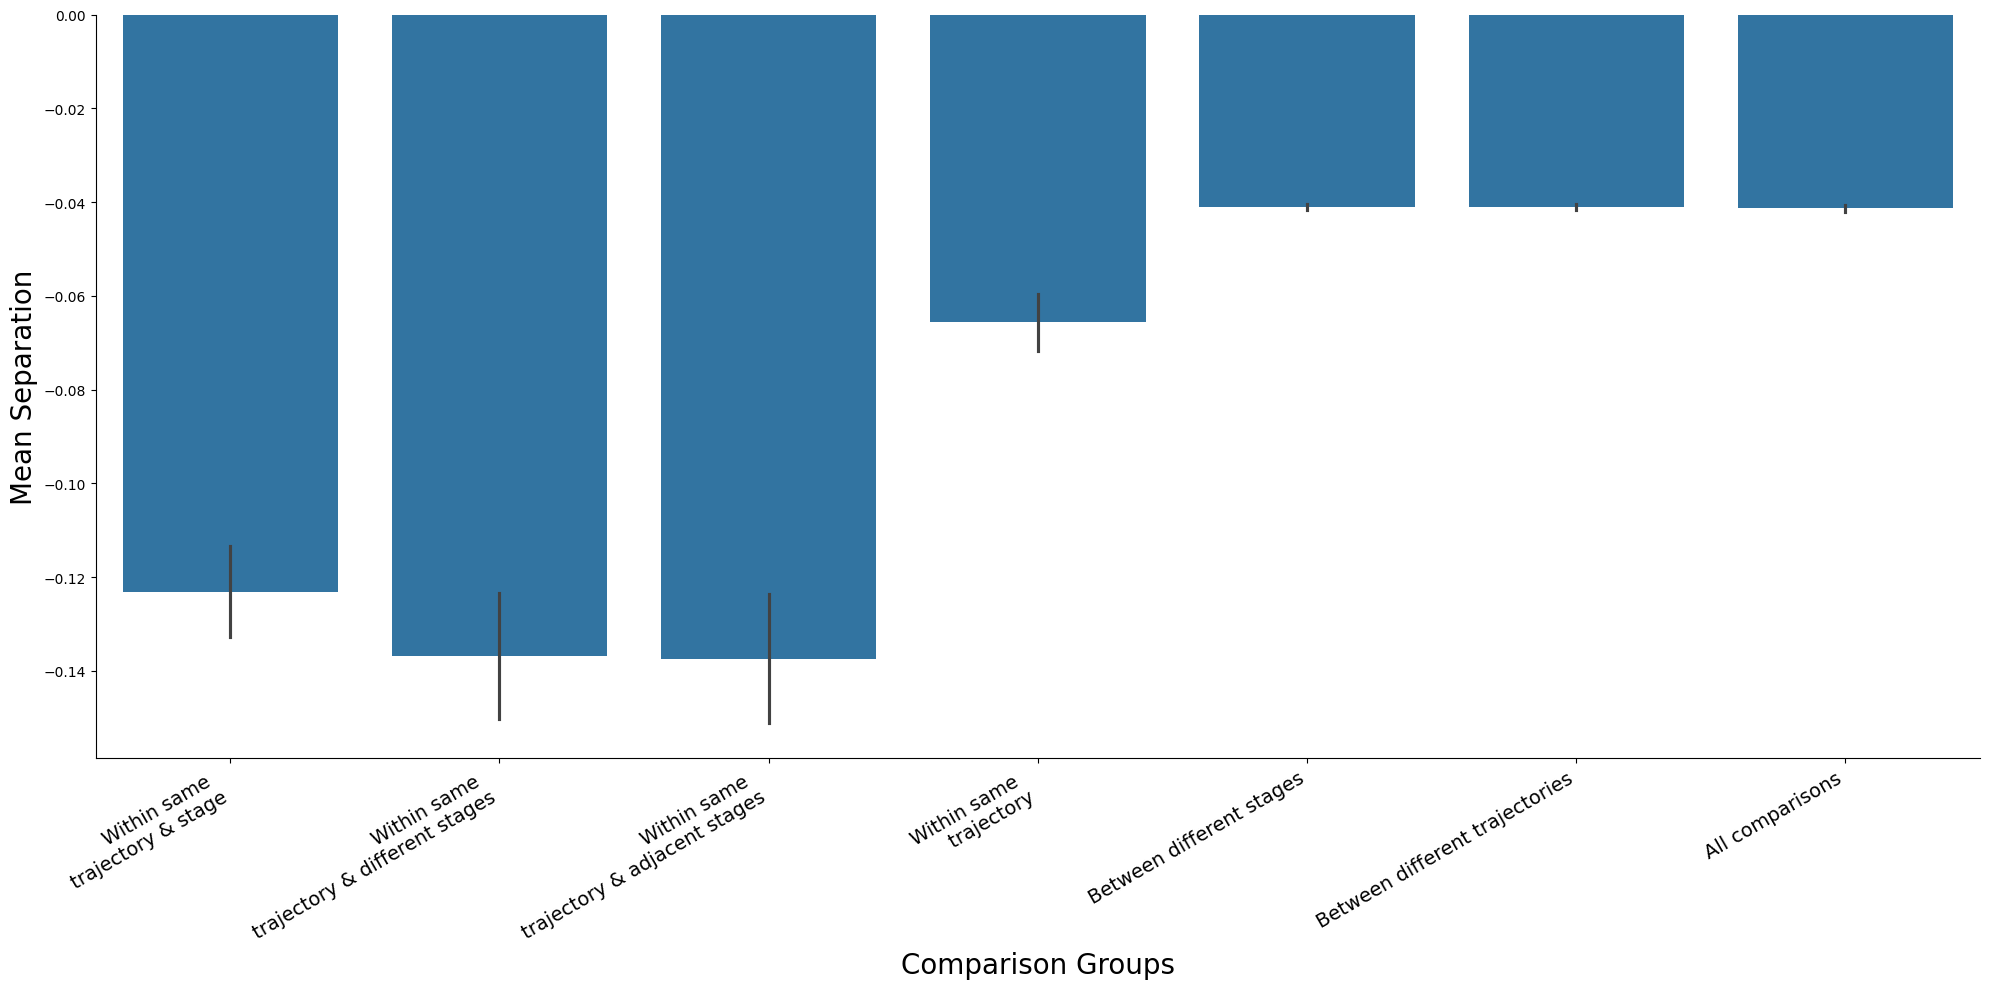

In [95]:

# Define custom labels for the plot
labels = [
    'Within same \n trajectory & stage',
    'Within same \n trajectory & different stages',
    'Within same \n trajectory & adjacent stages',
    'Within same \n trajectory',
    'Between different stages',
    'Between different trajectories',
    'All comparisons'
]

# Data lists (replace with your actual data)
comparing_group_list = [
    within_trj_time_sep_list,
    between_trj_time_sep_list,
    between_trj_adjacent_time_sep_list,
    same_trj_sep_list,
    never_same_trj_time_sep_list,
    never_same_trj_sep_list,
    all_dispairs_sep_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Separation": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Separation"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Separation", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Mean Separation', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjDisSeparation_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [96]:
#Temporal resolution

In [97]:
# Calculating Jaccard indices for each temporal step
temporal_step1_ji = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_jaccard_dict, 1)
temporal_step2_ji = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_jaccard_dict, 2)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in female_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-occurring in the same trajectory and time
never_same_trj_time_ji_list = [
    ji for dispair, ji in icd_genes_ppi_overlap_jaccard_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-occurring in the same trajectory
never_same_trj_ji_list = [
    ji for dispair, ji in icd_genes_ppi_overlap_jaccard_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair Jaccard indices
all_dispairs_ji_list = list(icd_genes_ppi_overlap_jaccard_dict.values())



/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/3696868469.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


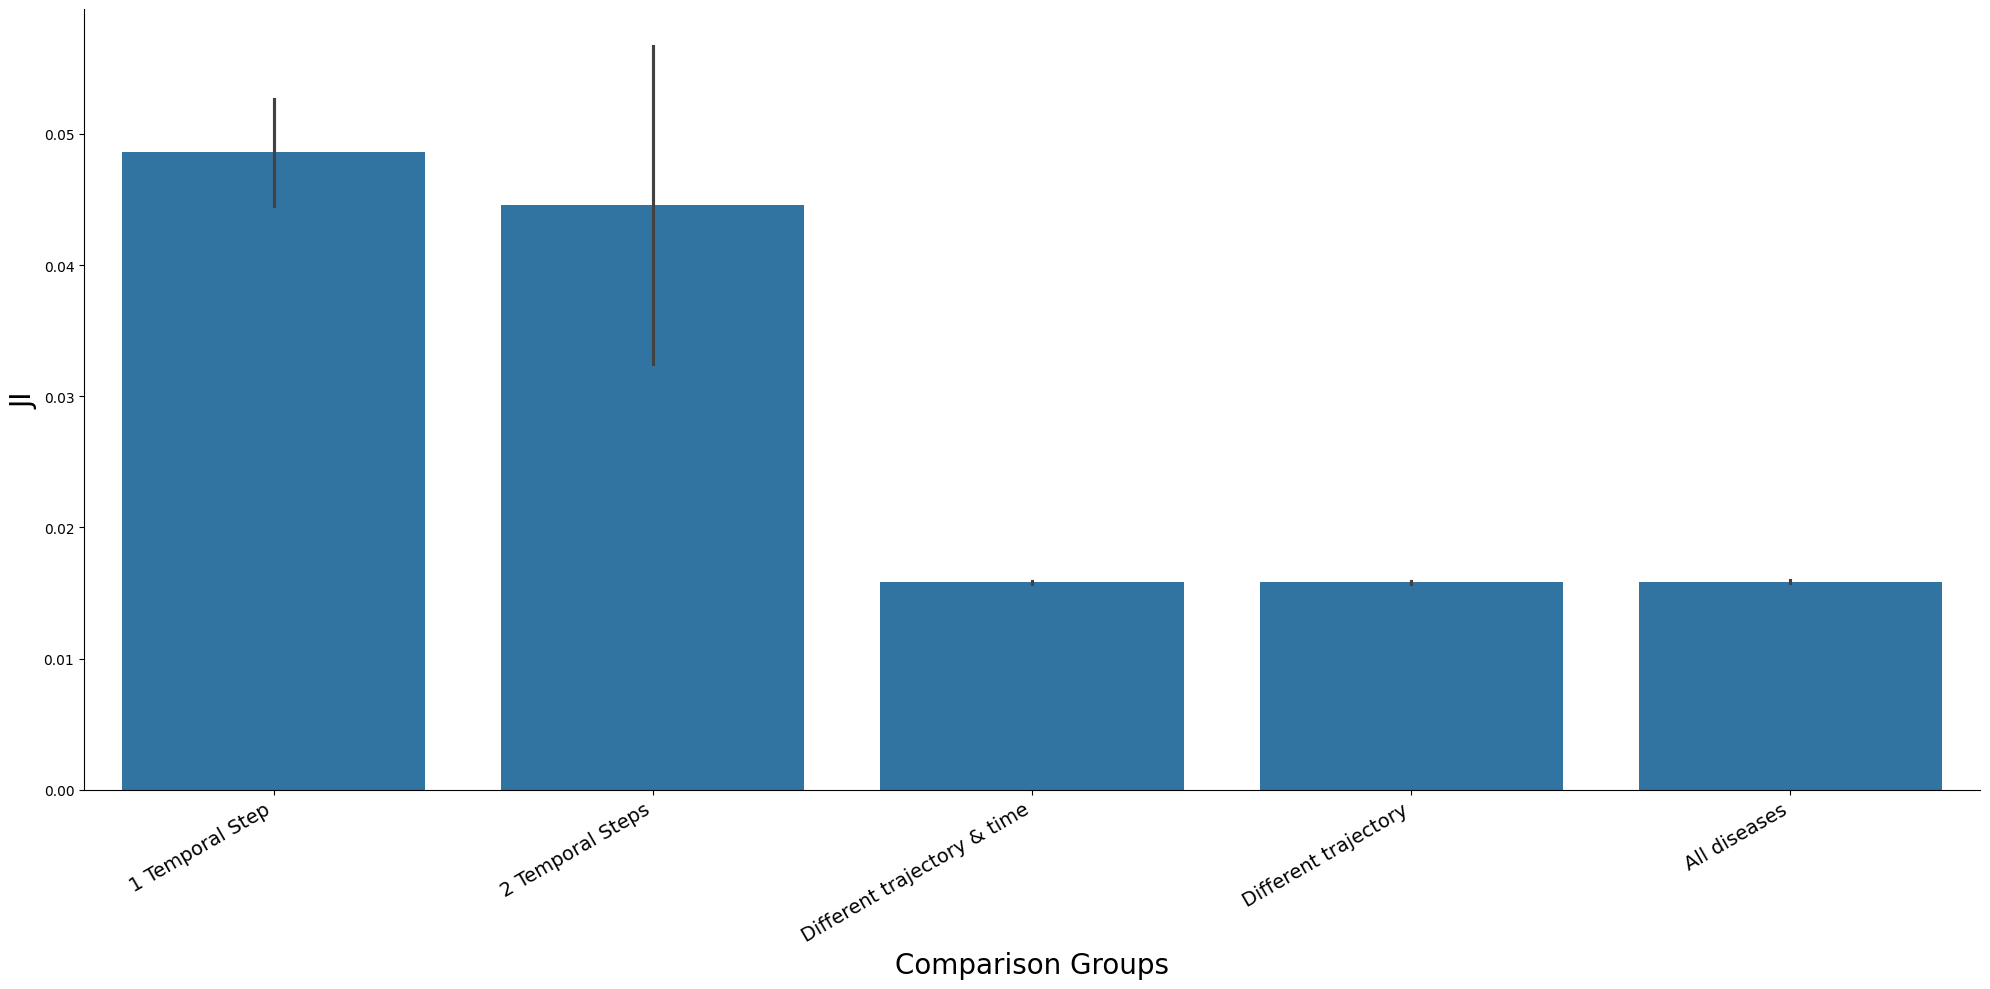

In [101]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_ji,
    temporal_step2_ji,
    never_same_trj_time_ji_list,
    never_same_trj_ji_list,
    all_dispairs_ji_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "JI": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["JI"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="JI", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('JI', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisJI_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [102]:
# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_oc = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_coefficient_dict, 1)
temporal_step2_oc = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_overlap_coefficient_dict, 2)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in female_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-occurring in the same trajectory and time
never_same_trj_time_oc_list = [
    oc for dispair, oc in icd_genes_ppi_overlap_coefficient_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-occurring in the same trajectory
never_same_trj_oc_list = [
    oc for dispair, oc in icd_genes_ppi_overlap_coefficient_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair OC indices
all_dispairs_oc_list = list(icd_genes_ppi_overlap_coefficient_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/2083124437.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


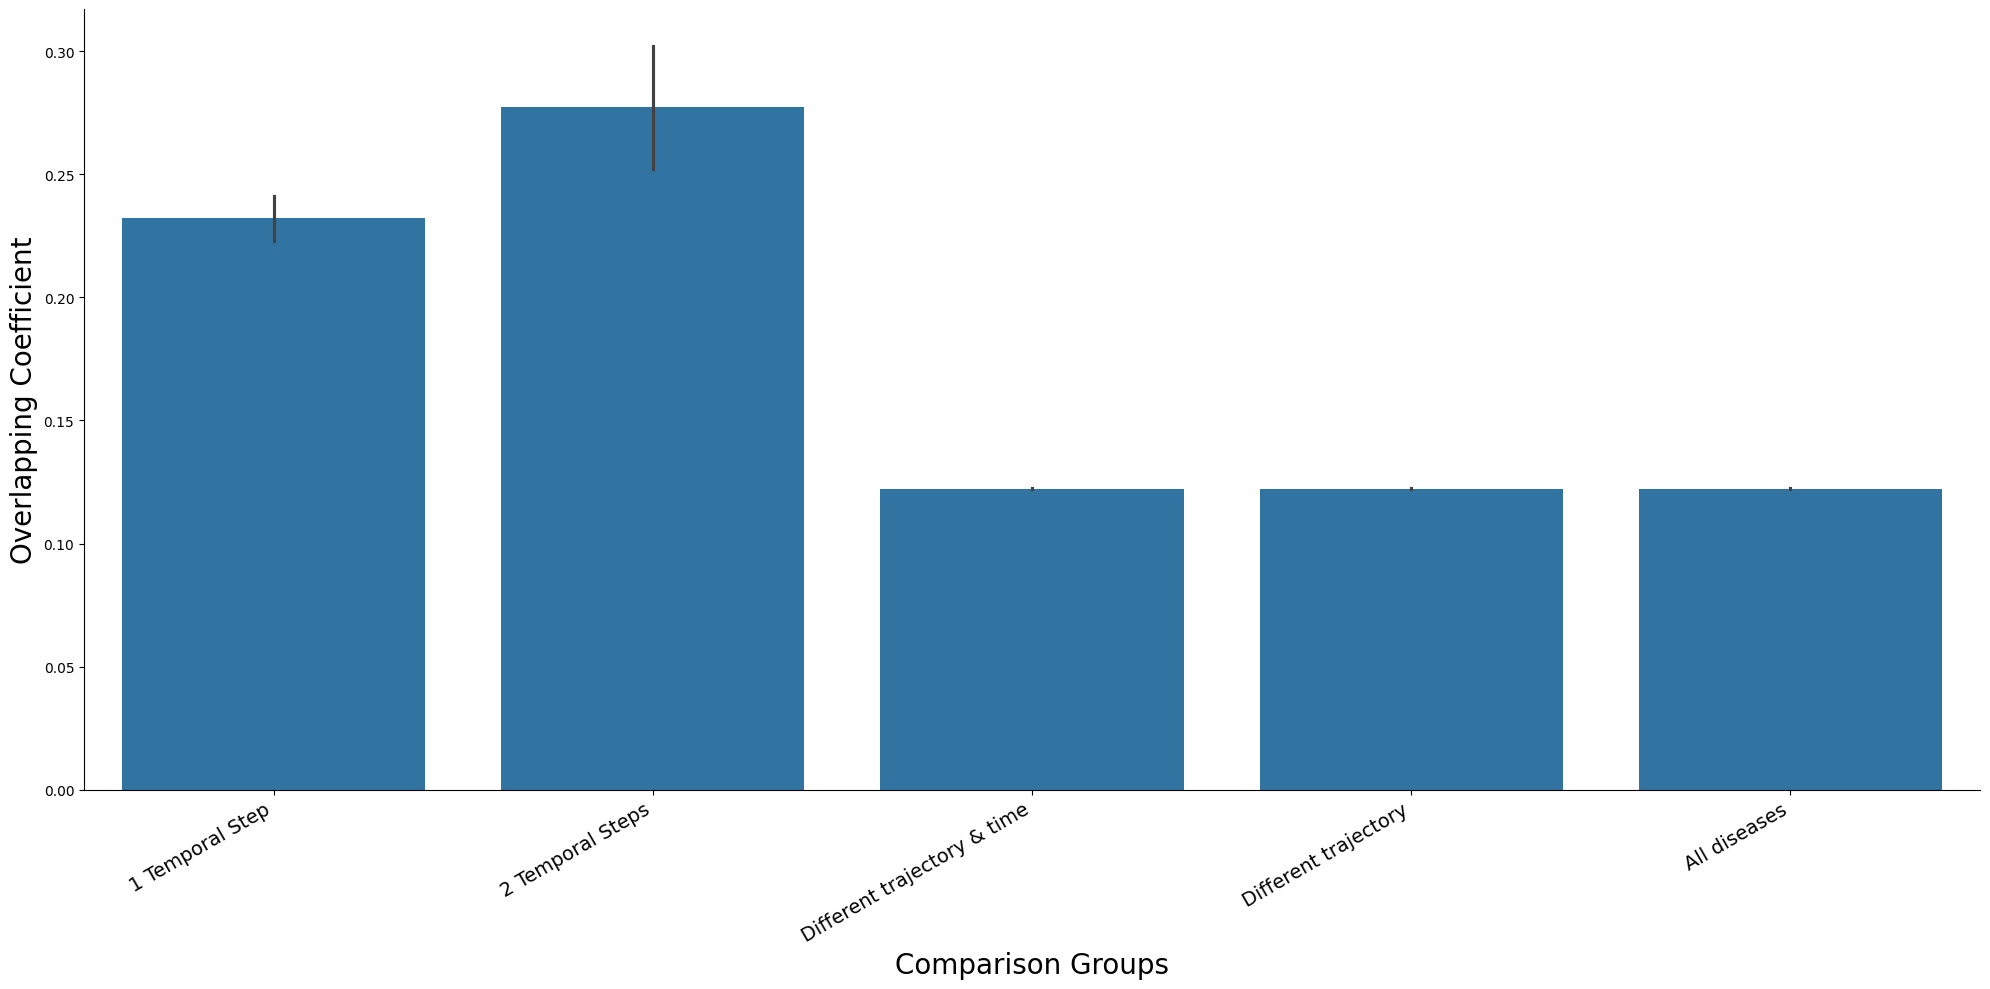

In [103]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_oc,
    temporal_step2_oc,
    never_same_trj_time_oc_list,
    never_same_trj_oc_list,
    all_dispairs_oc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "OC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["OC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="OC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Overlapping Coefficient', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisOC_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [104]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_aspdc = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_aspdc_dict, 1)
temporal_step2_aspdc = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_aspdc_dict, 2)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in female_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-aspdccurring in the same trajectory and time
never_same_trj_time_aspdc_list = [
    aspdc for dispair, aspdc in icd_genes_ppi_aspdc_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-aspdccurring in the same trajectory
never_same_trj_aspdc_list = [
    aspdc for dispair, aspdc in icd_genes_ppi_aspdc_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair ASPDC indices
all_dispairs_aspdc_list = list(icd_genes_ppi_aspdc_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/374911861.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


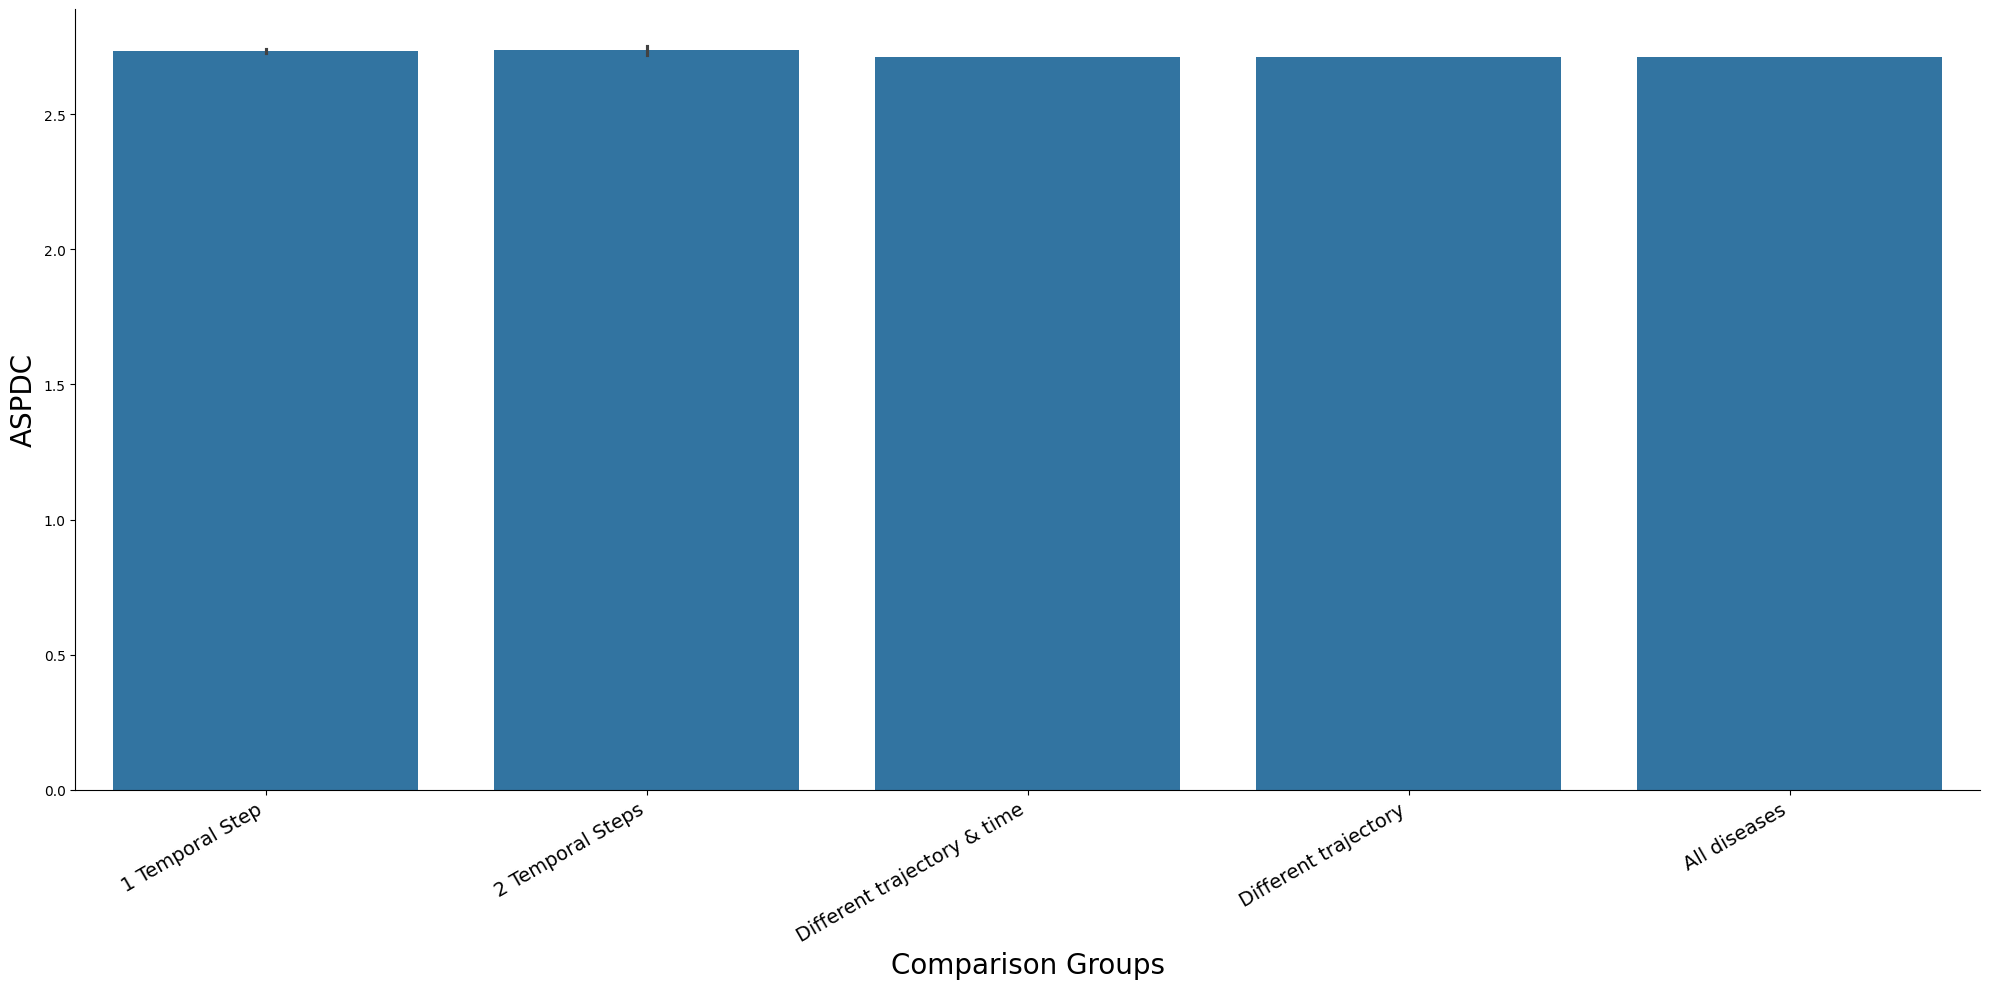

In [105]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_aspdc,
    temporal_step2_aspdc,
    never_same_trj_time_aspdc_list,
    never_same_trj_aspdc_list,
    all_dispairs_aspdc_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "ASPDC": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["ASPDC"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="ASPDC", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('ASPDC', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisASPDC_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [106]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_MinSHDis = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_mean_shortest_distance_dict, 1)
temporal_step2_MinSHDis = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_mean_shortest_distance_dict, 2)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in female_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-MinSHDiscurring in the same trajectory and time
never_same_trj_time_MinSHDis_list = [
    MinSHDis for dispair, MinSHDis in icd_genes_ppi_mean_shortest_distance_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-MinSHDiscurring in the same trajectory
never_same_trj_MinSHDis_list = [
    MinSHDis for dispair, MinSHDis in icd_genes_ppi_mean_shortest_distance_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair MinSHDis indices
all_dispairs_MinSHDis_list = list(icd_genes_ppi_mean_shortest_distance_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/1375580359.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


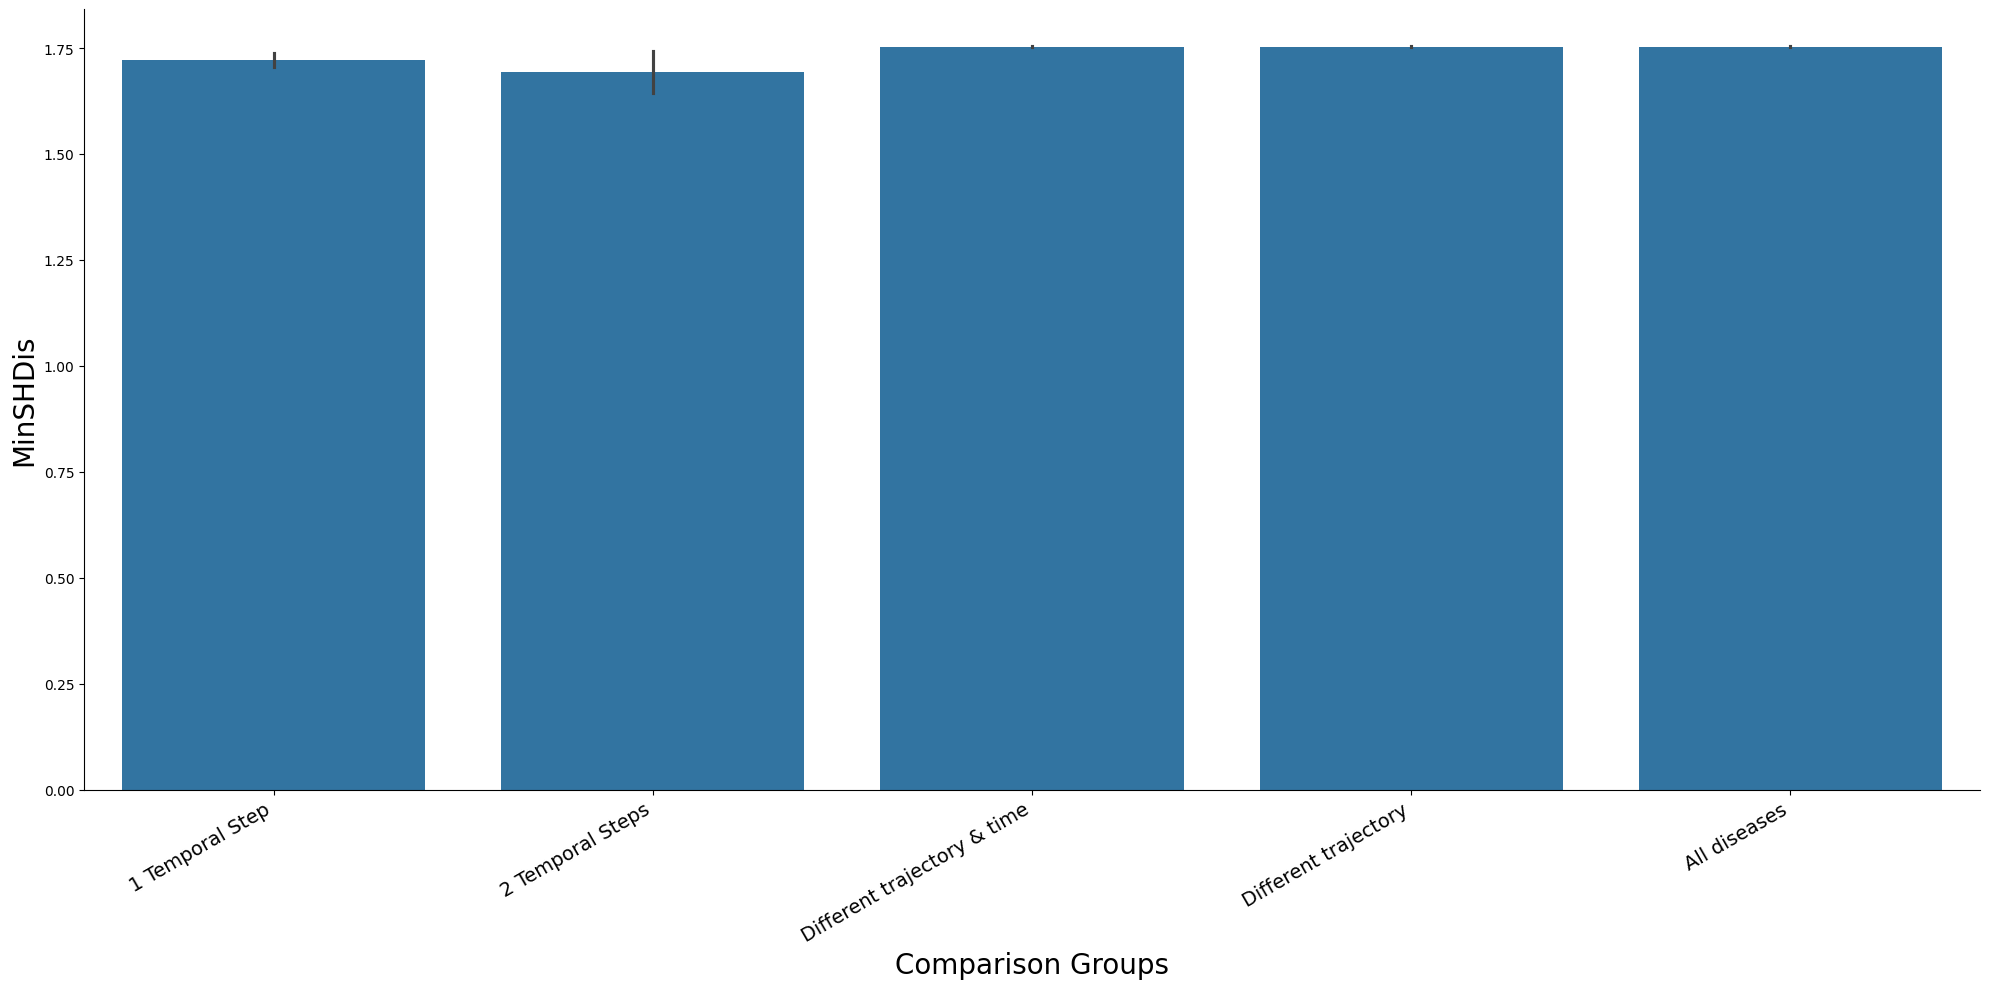

In [107]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_MinSHDis,
    temporal_step2_MinSHDis,
    never_same_trj_time_MinSHDis_list,
    never_same_trj_MinSHDis_list,
    all_dispairs_MinSHDis_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "MinSHDis": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["MinSHDis"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="MinSHDis", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('MinSHDis', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisMinSHDis_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [108]:

# Calculating Overlapping Coefficients indices for each temporal step
temporal_step1_sep = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_separation_dict, 1)
temporal_step2_sep = calculate_temporal_distance(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, icd_genes_ppi_separation_dict, 2)

# Generating disease combinations within the same trajectory and time
dis_combinations_among_trj_time_list = [
    pair
    for stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.values()
    for dislist in stage_dict.values()
    if len(dislist) > 1
    for pair in it.combinations(dislist, 2)
]

# Generating disease combinations within the same trajectory
dis_combinations_among_trj_list = [
    pair
    for dislist in female_trajectories_dict_filtered.values()
    for pair in it.combinations(dislist, 2)
]

# Diseases never co-sepcurring in the same trajectory and time
never_same_trj_time_sep_list = [
    sep for dispair, sep in icd_genes_ppi_separation_dict.items()
    if dispair not in dis_combinations_among_trj_time_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_time_list
]

# Diseases never co-sepcurring in the same trajectory
never_same_trj_sep_list = [
    sep for dispair, sep in icd_genes_ppi_separation_dict.items()
    if dispair not in dis_combinations_among_trj_list and (dispair[1], dispair[0]) not in dis_combinations_among_trj_list
]

# All disease pair separation indices
all_dispairs_sep_list = list(icd_genes_ppi_separation_dict.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_40394/1332561377.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')


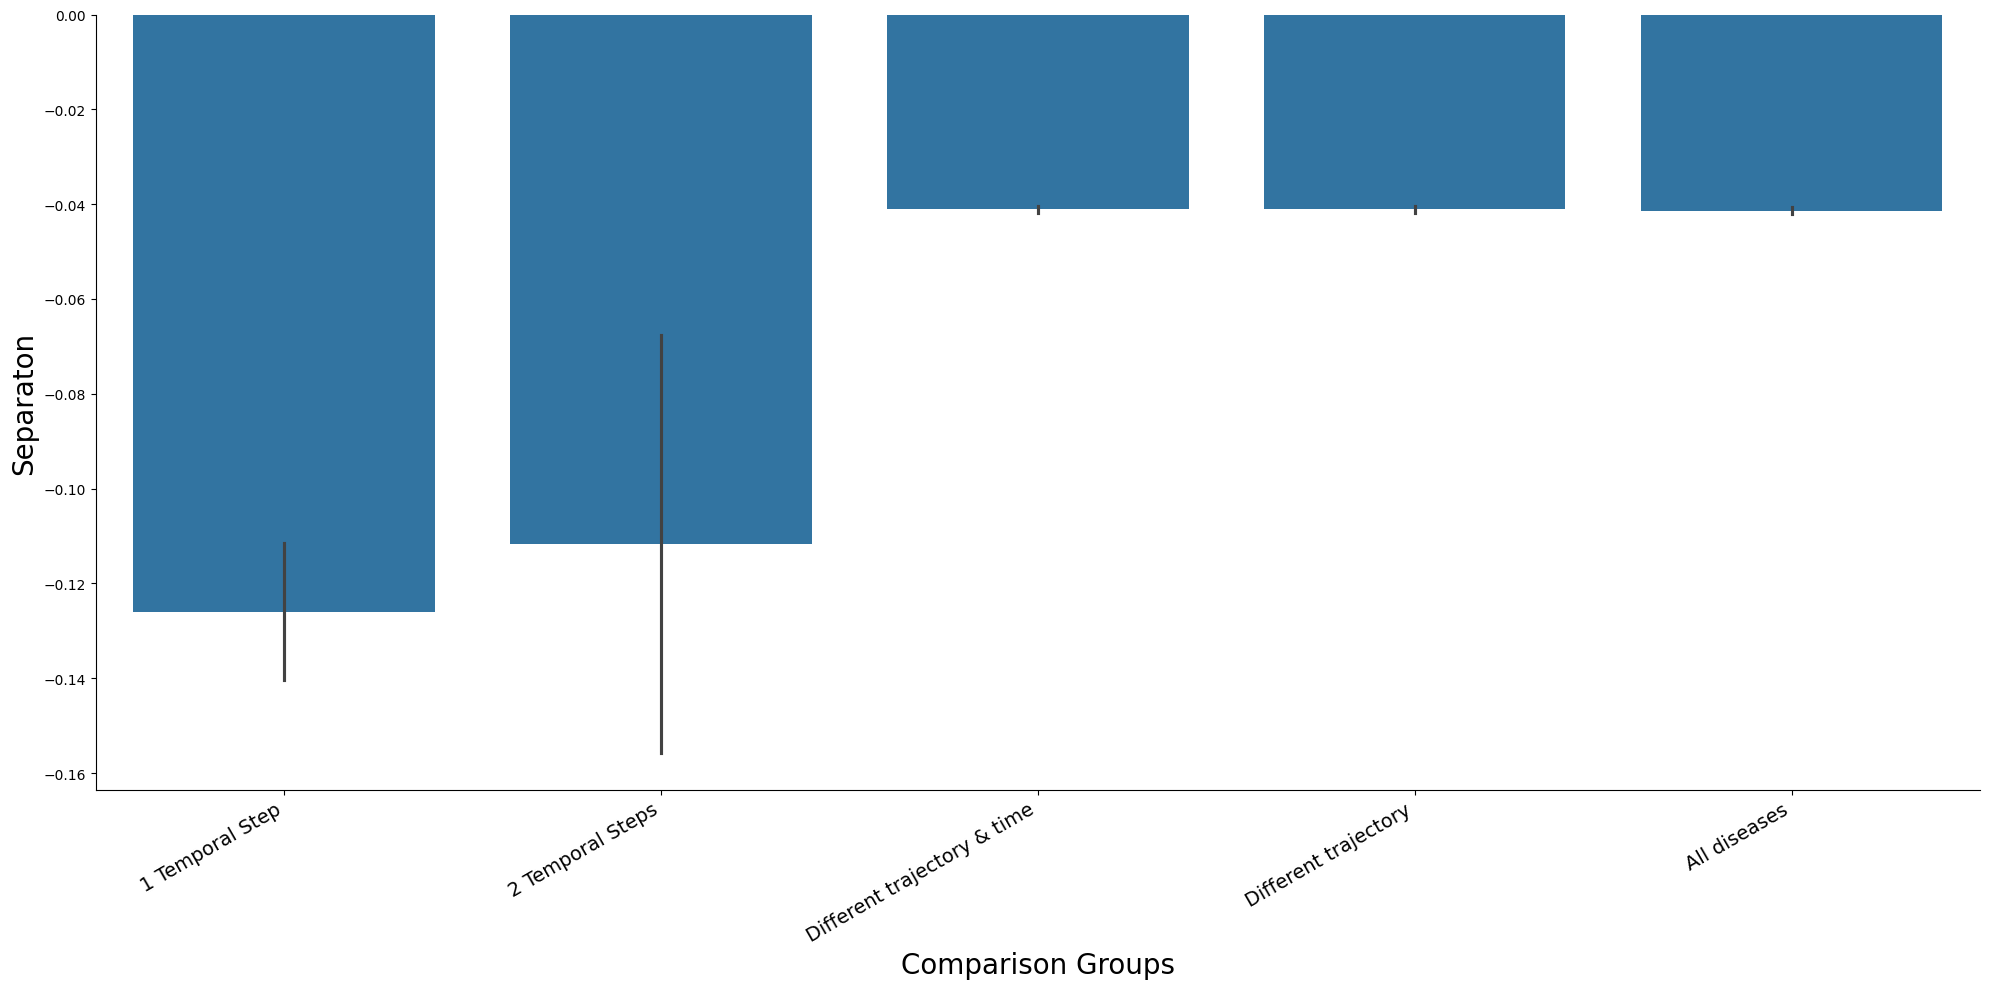

In [109]:

# Define custom labels for the plot
labels=['1 Temporal Step',
        '2 Temporal Steps',
        'Different trajectory & time',
        'Different trajectory',
        'All diseases']


# Create a list of data to plot, from original variable names
comparing_group_list = [
    temporal_step1_sep,
    temporal_step2_sep,
    never_same_trj_time_sep_list,
    never_same_trj_sep_list,
    all_dispairs_sep_list
]

# Convert lists to a DataFrame
data_dict = {"Group": [], "Separaton": []}
for label, data_list in zip(labels, comparing_group_list):
    data_dict["Group"].extend([label] * len(data_list))
    data_dict["Separaton"].extend(data_list)

df = pd.DataFrame(data_dict)

# Create the bar plot with error bars
fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.barplot(x="Group", y="Separaton", data=df, estimator='mean', errorbar='se', ax=ax1)

# Customize the plot
ax1.set_xticklabels(labels, fontsize=14, rotation=30, ha='right')
plt.ylabel('Separaton', fontsize=20)
plt.xlabel('Comparison Groups', fontsize=20)
sns.despine()

# Show the plot
plt.tight_layout()
plt.savefig('Figures/TrjStageDisSeparaton_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()